## 1. Setup and Imports

In [1]:
import os
import sys
from pathlib import Path
from typing import List, Tuple, Dict, Optional
import json

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from transformers import AutoTokenizer, AutoModelForTokenClassification
from peft import LoraConfig, get_peft_model, TaskType
from sklearn.metrics import confusion_matrix, classification_report

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
	print(f"Number of CUDA devices: {torch.cuda.device_count()}")
	for i in range(torch.cuda.device_count()):
		print(f"  Device {i}: {torch.cuda.get_device_name(i)}")

# Set device - auto-detect, with fallback to CPU
if torch.cuda.is_available():
	device = "cuda:0"  # Use first GPU if available
else:
	device = "cpu"
	
print(f"\nUsing device: {device}")

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


/home/dmoi/miniforge3/envs/esm3di/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch version: 2.9.1+cu128
CUDA available: True
Number of CUDA devices: 2
  Device 0: NVIDIA RTX PRO 4000 Blackwell
  Device 1: NVIDIA RTX PRO 4000 Blackwell

Using device: cuda:0


In [2]:
cd /home/dmoi/projects/ESM3di/

/home/dmoi/projects/ESM3di


In [3]:
#!foldseek databases ProstT5 weights tmp

## Create Test Set from BFVD Data

Create a small test set from the BFVD structural tokens dataset for evaluation.

In [4]:
from ESM3di_model import ESM3DiModel, read_fasta


def create_test_set_from_bfvd(
    aa_fasta_path: str, 
    three_di_fasta_path: str, 
    test_size: int = 100, 
    output_prefix: str = "test_data",
    random_seed: int = 42
) -> Tuple[str, str]:
    """
    Create a small test set from the BFVD dataset.
    
    Args:
        aa_fasta_path: Path to BFVD amino acid FASTA file
        three_di_fasta_path: Path to BFVD 3Di FASTA file (masked)
        test_size: Number of sequences to extract for test set
        output_prefix: Prefix for output files
        random_seed: Random seed for reproducible sampling
        
    Returns:
        Tuple of (test_aa_fasta_path, test_3di_fasta_path)
    """
    import random
    
    print(f"Creating test set from BFVD data...")
    print(f"Source AA FASTA: {aa_fasta_path}")
    print(f"Source 3Di FASTA: {three_di_fasta_path}")
    print(f"Test set size: {test_size}")
    print("-" * 80)
    
    # Set random seed for reproducibility
    random.seed(random_seed)
    np.random.seed(random_seed)
    
    # Read the full BFVD dataset
    print("Loading BFVD amino acid sequences...")
    aa_records = read_fasta(aa_fasta_path)
    print(f"✓ Loaded {len(aa_records)} AA sequences")
    
    print("Loading BFVD 3Di sequences...")
    three_di_records = read_fasta(three_di_fasta_path)
    print(f"✓ Loaded {len(three_di_records)} 3Di sequences")
    
    # Verify they match
    if len(aa_records) != len(three_di_records):
        raise ValueError(f"Mismatch: {len(aa_records)} AA sequences vs {len(three_di_records)} 3Di sequences")
    
    # Create header mapping for verification
    aa_headers = {header: i for i, (header, _) in enumerate(aa_records)}
    three_di_headers = {header: i for i, (header, _) in enumerate(three_di_records)}
    
    # Find common headers (should be all if datasets are aligned)
    common_headers = set(aa_headers.keys()) & set(three_di_headers.keys())
    print(f"✓ Found {len(common_headers)} matching sequence headers")
    
    if len(common_headers) < test_size:
        raise ValueError(f"Not enough matching sequences ({len(common_headers)}) for test set size ({test_size})")
    
    # Sample random sequences for test set
    selected_headers = random.sample(list(common_headers), test_size)
    print(f"✓ Selected {len(selected_headers)} sequences for test set")
    
    # Extract selected sequences
    test_aa_records = []
    test_3di_records = []
    
    for header in selected_headers:
        aa_idx = aa_headers[header]
        three_di_idx = three_di_headers[header]
        
        test_aa_records.append(aa_records[aa_idx])
        test_3di_records.append(three_di_records[three_di_idx])
    
    # Generate output file paths
    test_aa_path = f"{output_prefix}_aa.fasta"
    test_3di_path = f"{output_prefix}_3di_masked.fasta"
    test_3di_unmasked_path = f"{output_prefix}_3di.fasta"
    
    # Write test AA sequences
    print(f"Writing test AA sequences to {test_aa_path}...")
    with open(test_aa_path, 'w') as f:
        for header, seq in test_aa_records:
            f.write(f">{header}\n")
            # Write in lines of 80 characters
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Write test 3Di sequences (masked version)
    print(f"Writing test 3Di sequences (masked) to {test_3di_path}...")
    with open(test_3di_path, 'w') as f:
        for header, seq in test_3di_records:
            f.write(f">{header}\n")
            # Write in lines of 80 characters  
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Create unmasked version by removing mask characters
    print(f"Creating unmasked 3Di sequences for {test_3di_unmasked_path}...")
    unmasked_records = []
    mask_chars = {'X', 'x', '-', 'N', 'n'}  # Common mask characters
    
    for header, masked_seq in test_3di_records:
        # Remove mask characters to create "ground truth" 3Di
        # Note: This assumes the masked sequence has real 3Di chars that we can unmask
        # You may need to adjust this logic based on your masking strategy
        unmasked_seq = ''.join([c for c in masked_seq if c not in mask_chars])
        
        # If the sequence becomes too short after unmasking, keep some context
        if len(unmasked_seq) < len(masked_seq) * 0.5:  # Less than 50% remained
            # Use original sequence but replace masks with a default character
            unmasked_seq = masked_seq.replace('X', 'L').replace('x', 'L').replace('-', 'L').replace('N', 'L').replace('n', 'L')
        
        unmasked_records.append((header, unmasked_seq))
    
    # Write unmasked version
    with open(test_3di_unmasked_path, 'w') as f:
        for header, seq in unmasked_records:
            f.write(f">{header}\n")
            for i in range(0, len(seq), 80):
                f.write(f"{seq[i:i+80]}\n")
    
    # Print statistics
    seq_lengths = [len(seq) for _, seq in test_aa_records]
    print(f"\n✓ Test set created successfully!")
    print(f"Files created:")
    print(f"  - {test_aa_path} (amino acid sequences)")
    print(f"  - {test_3di_path} (3Di sequences - masked)")
    print(f"  - {test_3di_unmasked_path} (3Di sequences - unmasked)")
    print(f"\nSequence statistics:")
    print(f"  - Count: {len(test_aa_records)}")
    print(f"  - Length range: {min(seq_lengths)}-{max(seq_lengths)} residues")
    print(f"  - Mean length: {np.mean(seq_lengths):.1f} residues")
    print(f"  - Random seed used: {random_seed}")
    
    return test_aa_path, test_3di_unmasked_path

print("✓ Test set creation function defined")

✓ Test set creation function defined


In [36]:
# Configuration for BFVD test set creation
BFVD_CONFIG = {
    #'aa_fasta': '/mnt/data1/bfvd/training_set/bfvd_data_aa.fasta',
    #'three_di_fasta': '/mnt/data1/bfvd/training_set/bfvd_data_3di_masked.fasta',
	'aa_fasta': '/mnt/data1/metavir_esm3di/metavr_aa.fa',
    'three_di_fasta': '/mnt/data1/metavir_esm3di/metavr_3di.fa',
    'test_size': 500,  # Number of sequences for test set
    'output_prefix': 'test_data',  # Prefix for output files
    'random_seed': 42,  # For reproducible sampling
    'create_test_set': True,  # Set to False to skip test set creation
}

# Create test set from BFVD data
if BFVD_CONFIG['create_test_set']:
    print("Creating test set from BFVD structural tokens...")
    print("=" * 80)
    
    try:
        # Check if source files exist
        if not os.path.exists(BFVD_CONFIG['aa_fasta']):
            print(f"⚠ Warning: AA FASTA not found: {BFVD_CONFIG['aa_fasta']}")
            print("Please check the file path or mount point.")
        elif not os.path.exists(BFVD_CONFIG['three_di_fasta']):
            print(f"⚠ Warning: 3Di FASTA not found: {BFVD_CONFIG['three_di_fasta']}")
            print("Please check the file path or mount point.")
        else:
            # Create the test set
            test_aa_path, test_3di_path = create_test_set_from_bfvd(
                aa_fasta_path=BFVD_CONFIG['aa_fasta'],
                three_di_fasta_path=BFVD_CONFIG['three_di_fasta'],
                test_size=BFVD_CONFIG['test_size'],
                output_prefix=BFVD_CONFIG['output_prefix'],
                random_seed=BFVD_CONFIG['random_seed']
            )
            
            print(f"\n✓ Test set files ready for evaluation:")
            print(f"  - AA sequences: {test_aa_path}")
            print(f"  - 3Di sequences: {test_3di_path}")
            
            # Verify files were created
            if os.path.exists(test_aa_path) and os.path.exists(test_3di_path):
                print(f"✓ All test files created successfully!")
            else:
                print(f"⚠ Warning: Some test files may not have been created properly.")
                
    except Exception as e:
        print(f"✗ Error creating test set: {str(e)}")
        import traceback
        traceback.print_exc()
        print("\nFalling back to existing test files if available...")
        
else:
    print("⚠ Test set creation disabled in configuration")
    print("Using existing test files if available...")

print(f"\n{'='*80}")

Creating test set from BFVD structural tokens...
Creating test set from BFVD data...
Source AA FASTA: /mnt/data1/metavir_esm3di/metavr_aa.fa
Source 3Di FASTA: /mnt/data1/metavir_esm3di/metavr_3di.fa
Test set size: 500
--------------------------------------------------------------------------------
Loading BFVD amino acid sequences...
✓ Loaded 748927 AA sequences
Loading BFVD 3Di sequences...
✓ Loaded 748927 3Di sequences
✓ Found 748927 matching sequence headers
✓ Selected 500 sequences for test set
Writing test AA sequences to test_data_aa.fasta...
Writing test 3Di sequences (masked) to test_data_3di_masked.fasta...
Creating unmasked 3Di sequences for test_data_3di.fasta...

✓ Test set created successfully!
Files created:
  - test_data_aa.fasta (amino acid sequences)
  - test_data_3di_masked.fasta (3Di sequences - masked)
  - test_data_3di.fasta (3Di sequences - unmasked)

Sequence statistics:
  - Count: 500
  - Length range: 30-4506 residues
  - Mean length: 239.8 residues
  - Random 

## 2. Utility Functions

In [6]:
def load_checkpoint(checkpoint_path: str, device: str = 'cpu'):
	"""
	Load a model checkpoint and return model, tokenizer, and metadata.
	
	This function uses the same robust checkpoint loading logic as fastas2foldseekdb.py
	to ensure consistency across inference pipelines.
	
	Returns:
		model, tokenizer, label_vocab, mask_chars, config
	"""
	print(f"Loading checkpoint: {checkpoint_path}")
	
	# Load checkpoint
	checkpoint = torch.load(checkpoint_path, map_location=device)
	
	# Extract checkpoint metadata
	label_vocab = checkpoint['label_vocab']
	mask_chars = checkpoint.get('mask_label_chars', '')
	args_dict = checkpoint.get('args', {})
	
	epoch = checkpoint.get('epoch', 0)
	loss = checkpoint.get('loss', 0.0)

	print(f"  Checkpoint: epoch {epoch}, loss: {loss:.4f}")
	print(f"  Label vocab size: {len(label_vocab)}")
	print(f"  Mask characters: {mask_chars}")

	# Extract model configuration from checkpoint
	# Use same parameter names and defaults as fastas2foldseekdb.py
	hf_model_name = args_dict.get(
		'hf_model_name',
		args_dict.get('hf_model', 'facebook/esm2_t33_650M_UR50D')
	)
	num_labels = len(label_vocab)
	use_cnn_head = args_dict.get('use_cnn_head', False)
	lora_r = args_dict.get('lora_r', 8)
	lora_alpha = args_dict.get('lora_alpha', 16.0)
	lora_dropout = args_dict.get('lora_dropout', 0.05)
	lora_target_modules = checkpoint.get('lora_target_modules', None)
	cnn_num_layers = args_dict.get('cnn_num_layers', 2)
	cnn_kernel_size = args_dict.get('cnn_kernel_size', 3)
	cnn_dropout = args_dict.get('cnn_dropout', 0.1)
	
	print(f"  Base model: {hf_model_name}")
	print(f"  Use CNN head: {use_cnn_head}")
	if use_cnn_head:
		print(f"    CNN layers: {cnn_num_layers}, kernel: {cnn_kernel_size}, dropout: {cnn_dropout}")
	print(f"  LoRA config: r={lora_r}, alpha={lora_alpha}, dropout={lora_dropout}")

	# Load tokenizer with trust_remote_code=True for ESM++ models
	#tokenizer = AutoTokenizer.from_pretrained(hf_model_name, trust_remote_code=True)
	
	# Initialize model with all extracted parameters
	model = ESM3DiModel(
		hf_model_name=hf_model_name,
		num_labels=num_labels,
		lora_r=lora_r,
		lora_alpha=lora_alpha,
		lora_dropout=lora_dropout,
		target_modules=lora_target_modules,
		use_cnn_head=use_cnn_head,
		cnn_num_layers=cnn_num_layers,
		cnn_kernel_size=cnn_kernel_size,
		cnn_dropout=cnn_dropout
	)

	model = model.get_model()
	model.load_state_dict(checkpoint['model_state_dict'])
	model.to(device)
	model.eval()

	if model.base_model.tokenizer is not None:
		tokenizer = model.base_model.tokenizer
	else:
		#use auto tokenizer as fallback
		tokenizer = AutoTokenizer.from_pretrained(hf_model_name, trust_remote_code=True)
	
	print("✓ Checkpoint loaded successfully\n")
	
	return model, tokenizer, label_vocab, mask_chars, args_dict

print("✓ Checkpoint loader function defined")

✓ Checkpoint loader function defined


In [7]:
@torch.no_grad()
def predict_3di_batch(model, tokenizer, label_vocab, aa_sequences: List[str], 
					 device: str = 'cpu', batch_size: int = 8) -> List[str]:
	"""
	Predict 3Di sequences for a batch of amino acid sequences.
	
	Uses the same logic as ESM3DiModel.predict_from_fasta() for consistency.
	
	Args:
		model: Trained model in eval mode
		tokenizer: ESM tokenizer
		label_vocab: List of 3Di characters
		aa_sequences: List of amino acid sequence strings
		device: Device to run on
		batch_size: Number of sequences to process at once
		
	Returns:
		List of predicted 3Di sequence strings
	"""
	model.eval()
	idx2char = {i: c for i, c in enumerate(label_vocab)}
	
	all_predictions = []
	num_sequences = len(aa_sequences)
	
	# Process in batches with progress tracking
	for i in tqdm(range(0, num_sequences, batch_size), desc="Predicting 3Di"):
		batch_seqs = aa_sequences[i:i+batch_size]
		batch_num = i // batch_size + 1
		total_batches = (num_sequences + batch_size - 1) // batch_size
		
		# Tokenize batch
		enc = tokenizer(
			batch_seqs,
			return_tensors="pt",
			padding=True,
			truncation=True,
			add_special_tokens=True,
			return_special_tokens_mask=True,
		)
		enc = {k: v.to(device) for k, v in enc.items()}
		
		# Forward pass
		outputs = model(**enc)
		logits = outputs.logits  # [B, T, num_labels]
		special_mask = enc["special_tokens_mask"]  # [B, T]
		
		# Get predictions for each sequence in batch
		pred_indices = logits.argmax(dim=-1)  # [B, T]
		
		for b in range(len(batch_seqs)):
			pred_chars = []
			for j in range(pred_indices.shape[1]):
				if special_mask[b, j] == 1:
					# Skip special tokens (e.g., [CLS], [SEP])
					continue
				pred_chars.append(idx2char[int(pred_indices[b, j])])
			
			all_predictions.append("".join(pred_chars))
	
	return all_predictions

print("✓ Batch prediction function defined")


✓ Batch prediction function defined


In [8]:
@torch.no_grad()
def predict_3di_prost5(aa_sequences: List[str], device: str = 'cpu', batch_size: int = 1) -> List[str]:
	"""
	Predict 3Di sequences using ProST T5 via FoldSeek pipeline.
	
	Uses the run_foldseek_prostT5_pipeline function which:
	1. Creates a FoldSeek database from amino acid sequences
	2. Generates 3Di predictions
	3. Outputs 3Di characters in FASTA format
	
	Args:
		aa_sequences: List of amino acid sequence strings
		device: Device to run on (not used, included for API consistency)
		batch_size: Batch size for processing (not used with FoldSeek pipeline)
		
	Returns:
		List of predicted 3Di sequence strings
	"""
	try:
		import tempfile
		import shutil
		
		# Create temporary directory for this batch
		temp_dir = tempfile.mkdtemp(prefix='prost5_')
		
		try:
			# Write input sequences to temporary FASTA
			temp_input_fasta = os.path.join(temp_dir, 'input_aa.fasta')
			with open(temp_input_fasta, 'w') as f:
				for i, seq in enumerate(aa_sequences):
					f.write(f">seq_{i}\n{seq}\n")
			
			print(f"Running FoldSeek pipeline on {len(aa_sequences)} sequences...")
			
			# Run FoldSeek pipeline - returns path to 3Di FASTA
			output_3di_fasta = run_foldseek_prostT5_pipeline(
				temp_input_fasta, 
				output_dir=os.path.join(temp_dir, 'foldseek_db')
			)
			
			# Parse the output 3Di FASTA file
			if os.path.exists(output_3di_fasta):
				records = read_fasta(output_3di_fasta)
				all_predictions = [seq for _, seq in records]
				
				print(f"✓ Successfully generated {len(all_predictions)} 3Di predictions")
				return all_predictions
			else:
				print(f"⚠ Output FASTA file not found: {output_3di_fasta}")
				# Return placeholder predictions
				return ["N" * len(seq) for seq in aa_sequences]
		
		finally:
			# Clean up temporary directory
			if os.path.exists(temp_dir):
				shutil.rmtree(temp_dir)
				print(f"Cleaned up temporary directory: {temp_dir}")
	
	except FileNotFoundError as e:
		print(f"⚠ FoldSeek not found in PATH: {str(e)}")
		print("Please install FoldSeek: https://github.com/steineggerlab/foldseek")
		# Return placeholder predictions (all 'N' for unknown)
		return ["N" * len(seq) for seq in aa_sequences]
	
	except Exception as e:
		print(f"⚠ Error in ProST T5 prediction: {str(e)}")
		import traceback
		traceback.print_exc()
		print("Falling back to placeholder predictions")
		# Return placeholder predictions (all 'N' for unknown)
		return ["N" * len(seq) for seq in aa_sequences]

print("✓ ProST T5 prediction function defined (using FoldSeek pipeline)")


✓ ProST T5 prediction function defined (using FoldSeek pipeline)


## 3. Configuration

Configure paths to your checkpoints and test data files.

In [37]:
# Evaluation configuration (updated to use BFVD test set)
EVAL_CONFIG = {
	# Checkpoint directory and epochs to evaluate
	'checkpoint_dir': 'checkpoints_esmpp_bfvd',
	'checkpoint_path': None,  # Set to specific checkpoint path, or leave None to auto-select best
	'epochs_to_eval': None,  # None = all available, or list like [1, 2, 3]
	
	# Test data paths - will use files created by BFVD test set function
	'test_aa_fasta': f"{BFVD_CONFIG.get('output_prefix', 'test_data')}_aa.fasta",
	'test_3di_fasta': f"{BFVD_CONFIG.get('output_prefix', 'test_data')}_3di.fasta",  # Unmasked version for ground truth
	'test_3di_masked_fasta': f"{BFVD_CONFIG.get('output_prefix', 'test_data')}_3di.fasta",  # Masked version
	
	# Inference settings
	'batch_size': 4,  # Matching fastas2foldseekdb default
	'device': device,  # Use detected device from above
	'mask_char': 'X',
	
	# ProST T5 / FoldSeek comparison
	'include_prost5': True,  # Include ProST T5 predictions for comparison
	'prost5_batch_size': 1,  # ProST T5 typically runs with smaller batches
	
	# Output
	'output_dir': 'evaluation_results',
}

# Create output directory
os.makedirs(EVAL_CONFIG['output_dir'], exist_ok=True)

print("Evaluation Configuration:")
print("=" * 60)
for k, v in EVAL_CONFIG.items():
	if k != 'device':  # Skip printing device object
		print(f"  {k}: {v}")
print(f"  device: {EVAL_CONFIG['device']}")
print("=" * 60)
print(f"\n✓ Output directory: {EVAL_CONFIG['output_dir']}")


Evaluation Configuration:
  checkpoint_dir: checkpoints_esmpp_bfvd
  checkpoint_path: None
  epochs_to_eval: None
  test_aa_fasta: test_data_aa.fasta
  test_3di_fasta: test_data_3di.fasta
  test_3di_masked_fasta: test_data_3di.fasta
  batch_size: 4
  mask_char: X
  include_prost5: True
  prost5_batch_size: 1
  output_dir: evaluation_results
  device: cuda:0

✓ Output directory: evaluation_results


In [38]:
import subprocess


def run_foldseek_prostT5_pipeline(fasta_file: str, output_dir: str = 'foldseek_results') -> str:
	"""
	Run FoldSeek pipeline to generate 3Di predictions from a FASTA file.
	
	This function:
	1. Creates a FoldSeek database from the input FASTA
	2. Creates symbolic links for the database files
	3. Converts the database to FASTA format
	
	Args:
		fasta_file: Path to input amino acid FASTA file
		output_dir: Directory to store FoldSeek results
		
	Returns:
		Path to the generated 3Di FASTA file
	"""
	
	os.makedirs(output_dir, exist_ok=True)
	db_path = os.path.join(output_dir, 'queryDB')
	
	print(f"Running FoldSeek pipeline on {fasta_file}")
	print("=" * 80)
	
	try:
		# Step 1: Create FoldSeek database
		print("\n[1/3] Creating FoldSeek database...")
		cmd1 = f"foldseek createdb {fasta_file} {db_path} --prostt5-model weights --gpu 1"
		subprocess.run(cmd1, shell=True, check=True, capture_output=True)
		print("✓ Database created")
		
		# Step 2: Create symbolic links
		print("\n[2/3] Creating symbolic links...")
		cmd2 = f"foldseek lndb {db_path}_h {db_path}_ss_h"
		subprocess.run(cmd2, shell=True, check=True, capture_output=True)
		print("✓ Symbolic links created")
		
		# Step 3: Convert to FASTA
		print("\n[3/3] Converting to FASTA format...")
		cmd3 = f"foldseek convert2fasta {db_path}_ss {db_path}_ss.fasta"
		subprocess.run(cmd3, shell=True, check=True, capture_output=True)
		print("✓ FASTA conversion complete")
		
		fasta_output = f"{db_path}_ss.fasta"
		print(f"\n{'='*80}")
		print(f"✓ FoldSeek pipeline completed successfully")
		print(f"Output: {fasta_output}")
		
		return fasta_output
		
	except subprocess.CalledProcessError as e:
		print(f"✗ Error running FoldSeek command: {str(e)}", file=sys.stderr)
		raise

print("✓ FoldSeek pipeline function defined")


✓ FoldSeek pipeline function defined


## 4. Load Test Data

Load the test sequences and ground truth 3Di labels.

## Test Files Summary

The test set has been created from BFVD data. Here's what each file contains:
- **test_data_aa.fasta**: Amino acid sequences (input for model prediction)
- **test_data_3di.fasta**: Unmasked 3Di sequences (ground truth for evaluation)
- **test_data_3di_masked.fasta**: Masked 3Di sequences (original with mask tokens)

The evaluation will use:
1. AA sequences → Model predictions
2. Unmasked 3Di sequences → Ground truth for accuracy calculation
3. ProST T5 predictions via FoldSeek pipeline for comparison

In [39]:
# Load test amino acid sequences
print("Loading test data...")
test_aa_records = read_fasta(EVAL_CONFIG['test_aa_fasta'])
print(f"✓ Loaded {len(test_aa_records)} amino acid sequences")

# Load ground truth 3Di sequences (non-masked)
test_3di_records = read_fasta(EVAL_CONFIG['test_3di_fasta'])
print(f"✓ Loaded {len(test_3di_records)} 3Di sequences (ground truth)")

# Load masked 3Di sequences (if available)
if os.path.exists(EVAL_CONFIG['test_3di_masked_fasta']):
	test_3di_masked_records = read_fasta(EVAL_CONFIG['test_3di_masked_fasta'])
	print(f"✓ Loaded {len(test_3di_masked_records)} 3Di sequences (masked)")
else:
	test_3di_masked_records = None
	print("  Note: No masked 3Di file found (this is optional)")

# Verify alignment
assert len(test_aa_records) == len(test_3di_records), "Mismatch between AA and 3Di sequences"

# Create DataFrame for easier handling
test_data = pd.DataFrame({
	'header': [h for h, _ in test_aa_records],
	'aa_sequence': [s for _, s in test_aa_records],
	'true_3di': [s for _, s in test_3di_records],
})

if test_3di_masked_records:
	test_data['true_3di_masked'] = [s for _, s in test_3di_masked_records]

# Show sample
print("\nSample sequences:")
print(test_data.head())

# Compute statistics
test_data['seq_length'] = test_data['aa_sequence'].str.len()
print(f"\nSequence length statistics:")
print(test_data['seq_length'].describe())

Loading test data...
✓ Loaded 500 amino acid sequences
✓ Loaded 500 3Di sequences (ground truth)
✓ Loaded 500 3Di sequences (masked)

Sample sequences:
               header                                        aa_sequence  \
0  imgvr_pc_000221901  MAQILPLSSFDLTNPFESMQKLKQDQIDLDIKQTALENARKQMEQQ...   
1  imgvr_pc_000031795  MKVYTRQLCALVTKKIRLVEILAFSNIMKVCGLSDLHGNFIDIPEC...   
2  imgvr_pc_000318624  MGEGYQPIHKAQLDGSATESYDCGVIACAVGIDMATRGVKQPKRDH...   
3  imgvr_pc_000288698  MTLNVQDCINTIASIHGSALVAPQAIWCDRMLSTGRALAEVCGVSG...   
4  imgvr_pc_000745152  VPLTAAAPVADAVFIWVEVAVPLTAAAPVADAVFIWVEVAVPLTAA...   

                                            true_3di  \
0  DDDDDDPVQQDPVCPVSVVVVVVVVVVVVVVVVVVVVVVVVVVLVV...   
1  DVVVVVVVVVVVVVVVVVVVVVQVVQWFKEWEAEQCLCPDDAADAG...   
2  DDAAQQFDFAALPDPDPASVQCQLLRQLQRLLCQQQSPGRDDSCRL...   
3  DQDALVLLVQLCVVVVHDDDLPDDDDPSLVSLLSLVLQQDVLSVVD...   
4  DEDEDDADEEQEDEAEDEDADEYEYDAHEHQEYEYEYEYADEYEYA...   

                                     true_3di_masked  

In [40]:
#use foldseek prost5 to get predictions
if EVAL_CONFIG['include_prost5']:
	print("\nGenerating ProST T5 predictions via FoldSeek pipeline...")
	test_data['prost5_3di'] = predict_3di_prost5(
		test_data['aa_sequence'].tolist(),
		device=EVAL_CONFIG['device'],
		batch_size=EVAL_CONFIG['prost5_batch_size']
	)
	print("✓ ProST T5 predictions added to test data")


Generating ProST T5 predictions via FoldSeek pipeline...
Running FoldSeek pipeline on 500 sequences...
Running FoldSeek pipeline on /tmp/prost5_l1tlrse6/input_aa.fasta

[1/3] Creating FoldSeek database...
✓ Database created

[2/3] Creating symbolic links...
✓ Symbolic links created

[3/3] Converting to FASTA format...
✓ FASTA conversion complete

✓ FoldSeek pipeline completed successfully
Output: /tmp/prost5_l1tlrse6/foldseek_db/queryDB_ss.fasta
✓ Successfully generated 500 3Di predictions
Cleaned up temporary directory: /tmp/prost5_l1tlrse6
✓ ProST T5 predictions added to test data


## 5. Find Available Checkpoints

In [41]:
# Find all checkpoint files
checkpoint_dir = Path(EVAL_CONFIG['checkpoint_dir'])

if not checkpoint_dir.exists():
	print(f"Error: Checkpoint directory not found: {checkpoint_dir}")
	print(f"Please set 'checkpoint_dir' to a valid path")
	raise FileNotFoundError(f"Checkpoint directory: {checkpoint_dir}")

all_checkpoints = sorted(checkpoint_dir.glob('epoch_*.pt'))

if not all_checkpoints:
	print(f"Error: No checkpoints found in {checkpoint_dir}")
	print("Looking for files matching pattern: epoch_*.pt")
	raise FileNotFoundError(f"No checkpoints found in {checkpoint_dir}")

print(f"Found {len(all_checkpoints)} checkpoints in {checkpoint_dir}")

# Filter by requested epochs if specified
if EVAL_CONFIG['epochs_to_eval'] is not None:
	checkpoints_to_eval = [
		cp for cp in all_checkpoints 
		if any(f'epoch_{epoch}.pt' in cp.name for epoch in EVAL_CONFIG['epochs_to_eval'])
	]
	print(f"Filtering to requested epochs: {EVAL_CONFIG['epochs_to_eval']}")
else:
	checkpoints_to_eval = all_checkpoints
	print("Evaluating all available checkpoints")

print(f"\nCheckpoints to evaluate: ({len(checkpoints_to_eval)} total)")
for cp in checkpoints_to_eval:
	print(f"  - {cp.name}")

if not checkpoints_to_eval:
	print("\n⚠ No checkpoints selected for evaluation!")
	raise RuntimeError("No valid checkpoints found to evaluate")


Found 6 checkpoints in checkpoints_esmpp_bfvd
Evaluating all available checkpoints

Checkpoints to evaluate: (6 total)
  - epoch_1.pt
  - epoch_1_model.pt
  - epoch_2.pt
  - epoch_2_model.pt
  - epoch_3.pt
  - epoch_3_model.pt


## 6. Evaluation Metrics Functions

In [42]:
def calculate_accuracy(predictions: List[str], ground_truth: List[str], 
					  mask_char: str = 'X') -> Dict:
	"""
	Calculate various accuracy metrics.
	
	Args:
		predictions: List of predicted 3Di sequences
		ground_truth: List of true 3Di sequences
		mask_char: Character indicating masked positions (to ignore)
		
	Returns:
		Dictionary with accuracy metrics
	"""
	total_residues = 0
	correct_residues = 0
	total_sequences = len(predictions)
	perfect_sequences = 0
	
	per_seq_accuracies = []
	all_true_labels = []
	all_pred_labels = []
	
	for pred, true in zip(predictions, ground_truth):
		# Handle length mismatches
		min_len = min(len(pred), len(true))
		if len(pred) != len(true):
			print(f"Warning: Length mismatch - pred: {len(pred)}, true: {len(true)}")
		
		seq_correct = 0
		seq_total = 0
		
		for p, t in zip(pred[:min_len], true[:min_len]):
			# Skip masked positions
			if t == mask_char:
				continue
			
			seq_total += 1
			total_residues += 1
			
			if p == t:
				seq_correct += 1
				correct_residues += 1
			
			# Collect for confusion matrix
			all_true_labels.append(t)
			all_pred_labels.append(p)
		
		# Per-sequence accuracy
		if seq_total > 0:
			seq_acc = seq_correct / seq_total
			per_seq_accuracies.append(seq_acc)
			
			if seq_acc == 1.0:
				perfect_sequences += 1
	
	# Calculate overall metrics
	overall_accuracy = correct_residues / total_residues if total_residues > 0 else 0.0
	perfect_seq_percentage = perfect_sequences / total_sequences if total_sequences > 0 else 0.0
	mean_seq_accuracy = np.mean(per_seq_accuracies) if per_seq_accuracies else 0.0
	
	return {
		'overall_accuracy': overall_accuracy,
		'total_residues': total_residues,
		'correct_residues': correct_residues,
		'mean_sequence_accuracy': mean_seq_accuracy,
		'perfect_sequences': perfect_sequences,
		'perfect_sequence_percentage': perfect_seq_percentage,
		'per_sequence_accuracies': per_seq_accuracies,
		'true_labels': all_true_labels,
		'pred_labels': all_pred_labels,
	}

print("✓ Accuracy calculation function defined")

✓ Accuracy calculation function defined


## 7. Run Evaluation on All Checkpoints

This cell will evaluate all selected checkpoints and collect results.

In [43]:
from ESM3di_model import ESM3DiModel

In [44]:
# Store results for all checkpoints
all_results = []

print(f"Starting evaluation on {len(checkpoints_to_eval)} checkpoints")
print(f"Test set size: {len(test_data)} sequences")
print(f"Total residues: {test_data['seq_length'].sum():,}")
print("=" * 80)

for checkpoint_idx, checkpoint_path in enumerate(checkpoints_to_eval, 1):
	epoch_name = checkpoint_path.stem  # e.g., 'epoch_3'
	
	print(f"\n[{checkpoint_idx}/{len(checkpoints_to_eval)}] EVALUATING: {epoch_name}")
	print(f"Path: {checkpoint_path}")
	print("-" * 80)
	
	try:
		# Load checkpoint with robust logic from fastas2foldseekdb.py
		model, tokenizer, label_vocab, mask_chars, config = load_checkpoint(
			str(checkpoint_path), EVAL_CONFIG['device']
		)
		
		# Run predictions
		print("\nRunning predictions on test set...")
		aa_sequences = test_data['aa_sequence'].tolist()
		
		predictions = predict_3di_batch(
			model, tokenizer, label_vocab, aa_sequences,
			device=EVAL_CONFIG['device'], 
			batch_size=EVAL_CONFIG['batch_size']
		)
		
		print(f"✓ Generated {len(predictions)} predictions\n")
		
		# Validate predictions
		if len(predictions) != len(test_data):
			print(f"⚠ Warning: Expected {len(test_data)} predictions, got {len(predictions)}")
		
		# Calculate accuracy metrics
		print("Calculating accuracy metrics...")
		metrics = calculate_accuracy(
			predictions, 
			test_data['true_3di'].tolist(),
			mask_char=EVAL_CONFIG['mask_char']
		)
		
		# Print summary
		print(f"\n{'='*80}")
		print(f"RESULTS: {epoch_name}")
		print(f"{'='*80}")
		print(f"Overall Accuracy (per-residue):  {metrics['overall_accuracy']*100:.2f}%")
		print(f"Mean Sequence Accuracy:          {metrics['mean_sequence_accuracy']*100:.2f}%")
		print(f"Perfect Sequences:               {metrics['perfect_sequences']}/{len(test_data)} "
			  f"({metrics['perfect_sequence_percentage']*100:.2f}%)")
		print(f"Total Residues Evaluated:        {metrics['total_residues']:,}")
		print(f"Correct Predictions:             {metrics['correct_residues']:,}")
		print(f"{'='*80}\n")
		
		# Store results
		result = {
			'checkpoint': epoch_name,
			'checkpoint_path': str(checkpoint_path),
			'predictions': predictions,
			'metrics': metrics,
			'label_vocab': label_vocab,
			'config': config,
		}
		all_results.append(result)
		
	except Exception as e:
		print(f"✗ Error evaluating {epoch_name}: {str(e)}", file=sys.stderr)
		import traceback
		traceback.print_exc()
		continue
	
	finally:
		# Clean up
		if 'model' in locals():
			del model
		torch.cuda.empty_cache()
print(f"\n{'='*80}")
if all_results:
	print(f"✓ EVALUATION COMPLETE: {len(all_results)}/{len(checkpoints_to_eval)} checkpoints evaluated")
else:
	print("✗ EVALUATION FAILED: No checkpoints were successfully evaluated")
print(f"{'='*80}")


Starting evaluation on 6 checkpoints
Test set size: 500 sequences
Total residues: 119,917

[1/6] EVALUATING: epoch_1
Path: checkpoints_esmpp_bfvd/epoch_1.pt
--------------------------------------------------------------------------------
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_1.pt
  Checkpoint: epoch 1, loss: 1.4132
  Label vocab size: 20
  Mask characters: X
  Base model: Synthyra/ESMplusplus_small
  Use CNN head: False
  LoRA config: r=8, alpha=16.0, dropout=0.05

Loading model: Synthyra/ESMplusplus_small


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 'transformer.blocks.13.attn.out_proj'

Predicting 3Di: 100%|██████████| 125/125 [00:30<00:00,  4.05it/s]
✗ Error evaluating epoch_1_model: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL peft.peft_model.PeftModelForTokenClassification was not an allowed global by default. Please use `torch.serialization.add_safe_globals([peft.peft_model.PeftModelForTokenClassification])` or the `torch.serialization.safe_globals([peft.peft_model.PeftModelForTokenClassificati

✓ Generated 500 predictions

Calculating accuracy metrics...

RESULTS: epoch_1
Overall Accuracy (per-residue):  33.82%
Mean Sequence Accuracy:          44.96%
Perfect Sequences:               4/500 (0.80%)
Total Residues Evaluated:        117,128
Correct Predictions:             39,612


[2/6] EVALUATING: epoch_1_model
Path: checkpoints_esmpp_bfvd/epoch_1_model.pt
--------------------------------------------------------------------------------
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_1_model.pt

[3/6] EVALUATING: epoch_2
Path: checkpoints_esmpp_bfvd/epoch_2.pt
--------------------------------------------------------------------------------
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_2.pt
  Checkpoint: epoch 2, loss: 1.3268
  Label vocab size: 20
  Mask characters: X
  Base model: Synthyra/ESMplusplus_small
  Use CNN head: False
  LoRA config: r=8, alpha=16.0, dropout=0.05

Loading model: Synthyra/ESMplusplus_small


...

Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 'transformer.blocks.13.attn.out_proj'

Predicting 3Di: 100%|██████████| 125/125 [00:31<00:00,  3.98it/s]

✓ Generated 500 predictions

Calculating accuracy metrics...

RESULTS: epoch_3
Overall Accuracy (per-residue):  34.45%
Mean Sequence Accuracy:          45.56%
Perfect Sequences:               5/500 (1.00%)
Total Residues Evaluated:        117,128
Correct Predictions:             40,349


[6/6] EVALUATING: epoch_3_model
Path: checkpoints_esmpp_bfvd/epoch_3_model.pt
--------------------------------------------------------------------------------
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_3_model.pt

✓ EVALUATION COMPLETE: 3/6 checkpoints evaluated



✗ Error evaluating epoch_3_model: Weights only load failed. This file can still be loaded, to do so you have two options, do those steps only if you trust the source of the checkpoint. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL peft.peft_model.PeftModelForTokenClassification was not an allowed global by default. Please use `torch.serialization.add_safe_globals([peft.peft_model.PeftModelForTokenClassification])` or the `torch.serialization.safe_globals([peft.peft_model.PeftModelForTokenClassification])` context manager to allowlist this global if you trust this 

In [55]:

# Optional: Run ProST T5 predictions for comparison
if EVAL_CONFIG['include_prost5']:
	print(f"\n\n{'='*80}")
	print("RUNNING PROST T5 PREDICTIONS FOR COMPARISON")
	print(f"{'='*80}\n")
	
	try:
		print("Generating ProST T5 predictions on test set...")
		aa_sequences = test_data['aa_sequence'].tolist()
		
		prost5_predictions = predict_3di_prost5(
			aa_sequences,
			device=EVAL_CONFIG['device'],
			batch_size=EVAL_CONFIG['prost5_batch_size']
		)
		
		print(f"✓ Generated {len(prost5_predictions)} ProST T5 predictions\n")
		
		# Calculate accuracy metrics for ProST T5
		print("Calculating ProST T5 accuracy metrics...")
		prost5_metrics = calculate_accuracy(
			prost5_predictions,
			test_data['true_3di'].tolist(),
			mask_char=EVAL_CONFIG['mask_char']
		)
		
		# Print ProST T5 summary
		print(f"\n{'='*80}")
		print("PROST T5 RESULTS (Foundation Model)")
		print(f"{'='*80}")
		print(f"Overall Accuracy (per-residue):  {prost5_metrics['overall_accuracy']*100:.2f}%")
		print(f"Mean Sequence Accuracy:          {prost5_metrics['mean_sequence_accuracy']*100:.2f}%")
		print(f"Perfect Sequences:               {prost5_metrics['perfect_sequences']}/{len(test_data)} "
			  f"({prost5_metrics['perfect_sequence_percentage']*100:.2f}%)")
		print(f"Total Residues Evaluated:        {prost5_metrics['total_residues']:,}")
		print(f"Correct Predictions:             {prost5_metrics['correct_residues']:,}")
		print(f"{'='*80}\n")
		
		# Add ProST T5 as a special result
		prost5_result = {
			'checkpoint': 'ProST T5 (Foundation)',
			'checkpoint_path': 'foundation_model',
			'predictions': prost5_predictions,
			'metrics': prost5_metrics,
			'label_vocab': list(set(prost5_metrics['true_labels'] + prost5_metrics['pred_labels'])),
			'config': {'model_type': 'prost5_foundation'},
			'is_foundation': True,
		}
		all_results.append(prost5_result)
		
	except Exception as e:
		print(f"✗ Error running ProST T5: {str(e)}", file=sys.stderr)
		print("Continuing without ProST T5 comparison")
		prost5_result = None

else:
	print("\n⚠ ProST T5 comparison disabled in configuration")
	prost5_result = None




RUNNING PROST T5 PREDICTIONS FOR COMPARISON

Generating ProST T5 predictions on test set...
Running FoldSeek pipeline on 500 sequences...
Running FoldSeek pipeline on /tmp/prost5_mojzs75p/input_aa.fasta

[1/3] Creating FoldSeek database...
✓ Database created

[2/3] Creating symbolic links...
✓ Symbolic links created

[3/3] Converting to FASTA format...
✓ FASTA conversion complete

✓ FoldSeek pipeline completed successfully
Output: /tmp/prost5_mojzs75p/foldseek_db/queryDB_ss.fasta
✓ Successfully generated 500 3Di predictions
Cleaned up temporary directory: /tmp/prost5_mojzs75p
✓ Generated 500 ProST T5 predictions

Calculating ProST T5 accuracy metrics...

PROST T5 RESULTS (Foundation Model)
Overall Accuracy (per-residue):  16.91%
Mean Sequence Accuracy:          18.50%
Perfect Sequences:               0/500 (0.00%)
Total Residues Evaluated:        61,040
Correct Predictions:             10,319



## 8. Compare Results Across Checkpoints

In [56]:
# Create comparison DataFrame
comparison_data = []

for result in all_results:
	metrics = result['metrics']
	model_type = "Fine-tuned" if not result.get('is_foundation', False) else "Foundation"
	comparison_data.append({
		'Model': result['checkpoint'],
		'Type': model_type,
		'Overall Accuracy (%)': metrics['overall_accuracy'] * 100,
		'Mean Sequence Accuracy (%)': metrics['mean_sequence_accuracy'] * 100,
		'Perfect Sequences (%)': metrics['perfect_sequence_percentage'] * 100,
		'Total Residues': metrics['total_residues'],
		'Correct Residues': metrics['correct_residues'],
	})

comparison_df = pd.DataFrame(comparison_data)

print("\nPerformance Comparison: Fine-tuned vs Foundation Models")
print("=" * 100)
print(comparison_df.to_string(index=False))
print("=" * 100)

# Save to CSV
output_csv = os.path.join(EVAL_CONFIG['output_dir'], 'checkpoint_comparison.csv')
comparison_df.to_csv(output_csv, index=False)
print(f"\n✓ Saved comparison to {output_csv}")

# Print insights
print("\n\nKey Insights:")
print("-" * 100)
if prost5_result is not None:
	best_finetuned = max([r for r in all_results if not r.get('is_foundation', False)], 
						 key=lambda x: x['metrics']['overall_accuracy'])
	prost5_acc = prost5_result['metrics']['overall_accuracy'] * 100
	best_ft_acc = best_finetuned['metrics']['overall_accuracy'] * 100
	improvement = best_ft_acc - prost5_acc
	
	print(f"Best Fine-tuned: {best_finetuned['checkpoint']} ({best_ft_acc:.2f}%)")
	print(f"ProST T5 (Foundation): {prost5_acc:.2f}%")
	
	if improvement > 0:
		print(f"✓ Fine-tuned model improves by {improvement:.2f}% over ProST T5 foundation")
	elif improvement < 0:
		print(f"⚠ ProST T5 foundation outperforms by {abs(improvement):.2f}%")
	else:
		print("Note: Fine-tuned and foundation models have comparable performance")
else:
	best_result = max(all_results, key=lambda x: x['metrics']['overall_accuracy'])
	print(f"Best Model: {best_result['checkpoint']} ({best_result['metrics']['overall_accuracy']*100:.2f}%)")



Performance Comparison: Fine-tuned vs Foundation Models
                Model       Type  Overall Accuracy (%)  Mean Sequence Accuracy (%)  Perfect Sequences (%)  Total Residues  Correct Residues
              epoch_1 Fine-tuned             33.819411                   44.956047                    0.8          117128             39612
              epoch_2 Fine-tuned             34.370945                   45.404604                    1.0          117128             40258
              epoch_3 Fine-tuned             34.448637                   45.560568                    1.0          117128             40349
ProST T5 (Foundation) Foundation             16.905308                   18.498985                    0.0           61040             10319
ProST T5 (Foundation) Foundation             16.905308                   18.498985                    0.0           61040             10319

✓ Saved comparison to evaluation_results/checkpoint_comparison.csv


Key Insights:
-------------------

## 9. Visualize Performance Across Checkpoints

✓ Saved plot to evaluation_results/checkpoint_comparison_with_foundation.png


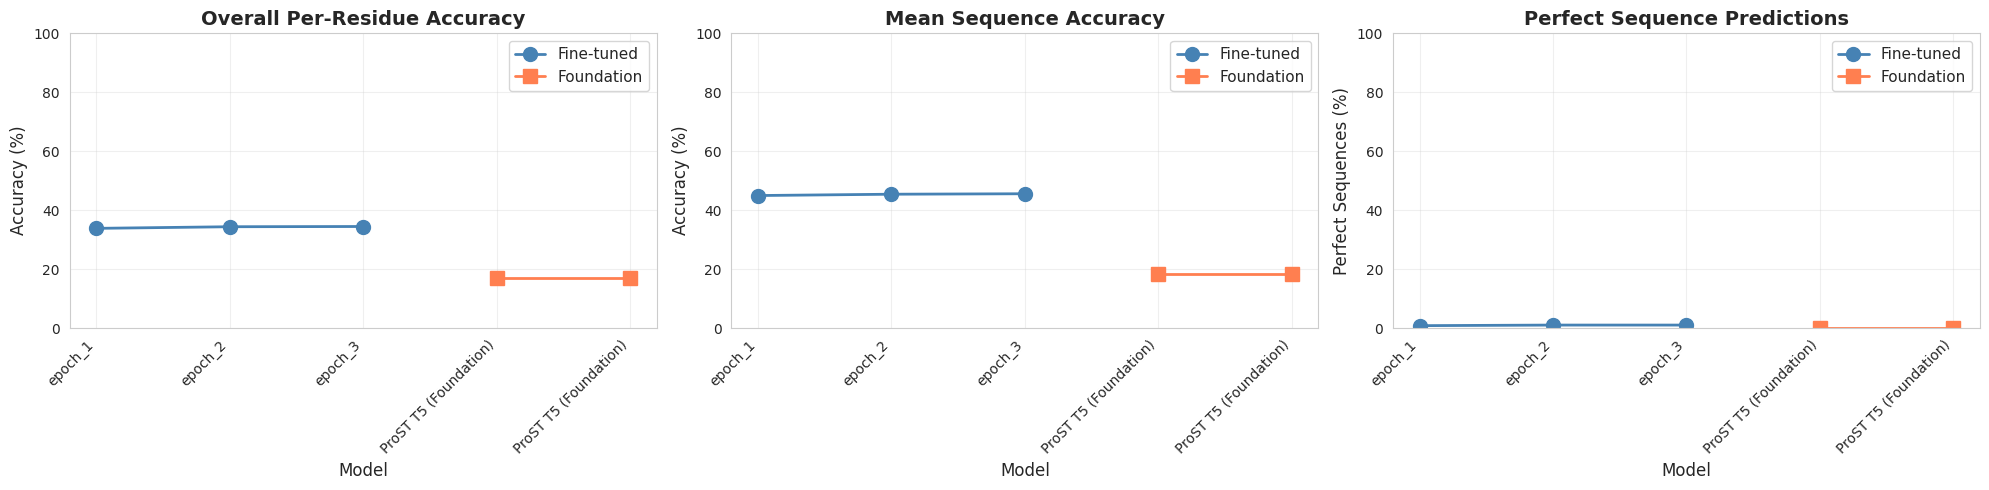

In [57]:
# Plot accuracy metrics across checkpoints and foundation models
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Separate fine-tuned and foundation models
finetuned_df = comparison_df[comparison_df['Type'] == 'Fine-tuned'].reset_index(drop=True)
foundation_df = comparison_df[comparison_df['Type'] == 'Foundation'].reset_index(drop=True)

colors_ft = 'steelblue'
colors_foundation = 'coral'

# Overall Accuracy
if len(finetuned_df) > 0:
	axes[0].plot(finetuned_df.index, finetuned_df['Overall Accuracy (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[0].plot(len(finetuned_df) + foundation_df.index, foundation_df['Overall Accuracy (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[0].set_xlabel('Model', fontsize=12)
axes[0].set_ylabel('Accuracy (%)', fontsize=12)
axes[0].set_title('Overall Per-Residue Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(comparison_df)))
axes[0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim([0, 100])
axes[0].legend(fontsize=11)

# Mean Sequence Accuracy
if len(finetuned_df) > 0:
	axes[1].plot(finetuned_df.index, finetuned_df['Mean Sequence Accuracy (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[1].plot(len(finetuned_df) + foundation_df.index, foundation_df['Mean Sequence Accuracy (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[1].set_xlabel('Model', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Mean Sequence Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xticks(range(len(comparison_df)))
axes[1].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0, 100])
axes[1].legend(fontsize=11)

# Perfect Sequences
if len(finetuned_df) > 0:
	axes[2].plot(finetuned_df.index, finetuned_df['Perfect Sequences (%)'], 
				 'o-', linewidth=2, markersize=10, color=colors_ft, label='Fine-tuned')
if len(foundation_df) > 0:
	axes[2].plot(len(finetuned_df) + foundation_df.index, foundation_df['Perfect Sequences (%)'], 
				 's-', linewidth=2, markersize=10, color=colors_foundation, label='Foundation')

axes[2].set_xlabel('Model', fontsize=12)
axes[2].set_ylabel('Perfect Sequences (%)', fontsize=12)
axes[2].set_title('Perfect Sequence Predictions', fontsize=14, fontweight='bold')
axes[2].set_xticks(range(len(comparison_df)))
axes[2].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim([0, 100])
axes[2].legend(fontsize=11)

plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'checkpoint_comparison_with_foundation.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved plot to {plot_path}")
plt.show()


## 10. Per-Sequence Accuracy Distribution

Visualize the distribution of per-sequence accuracies for each checkpoint.

✓ Saved plot to evaluation_results/sequence_accuracy_distributions.png


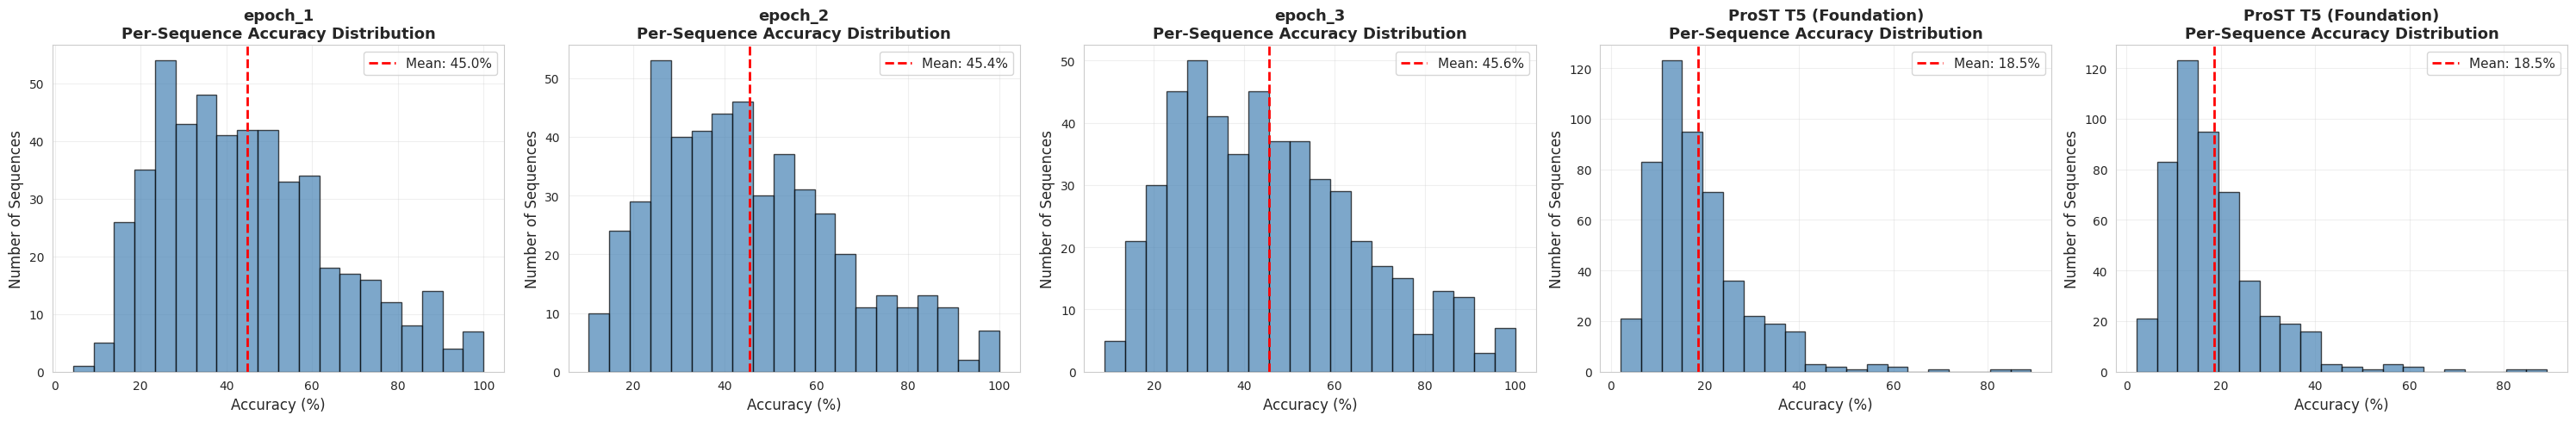

In [58]:
# Plot per-sequence accuracy distributions
fig, axes = plt.subplots(1, len(all_results), figsize=(6*len(all_results), 5))

if len(all_results) == 1:
	axes = [axes]

for idx, result in enumerate(all_results):
	per_seq_acc = np.array(result['metrics']['per_sequence_accuracies']) * 100
	
	axes[idx].hist(per_seq_acc, bins=20, color='steelblue', alpha=0.7, edgecolor='black')
	axes[idx].axvline(per_seq_acc.mean(), color='red', linestyle='--', 
					 linewidth=2, label=f'Mean: {per_seq_acc.mean():.1f}%')
	axes[idx].set_xlabel('Accuracy (%)', fontsize=12)
	axes[idx].set_ylabel('Number of Sequences', fontsize=12)
	axes[idx].set_title(f"{result['checkpoint']}\nPer-Sequence Accuracy Distribution", 
					   fontsize=13, fontweight='bold')
	axes[idx].legend(fontsize=11)
	axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'sequence_accuracy_distributions.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved plot to {plot_path}")
plt.show()

## 11. Confusion Matrix (Best Checkpoint)

Generate a confusion matrix for the best performing checkpoint.

Best checkpoint: epoch_3
Overall accuracy: 34.45%

✓ Saved confusion matrix to evaluation_results/confusion_matrix_epoch_3.png


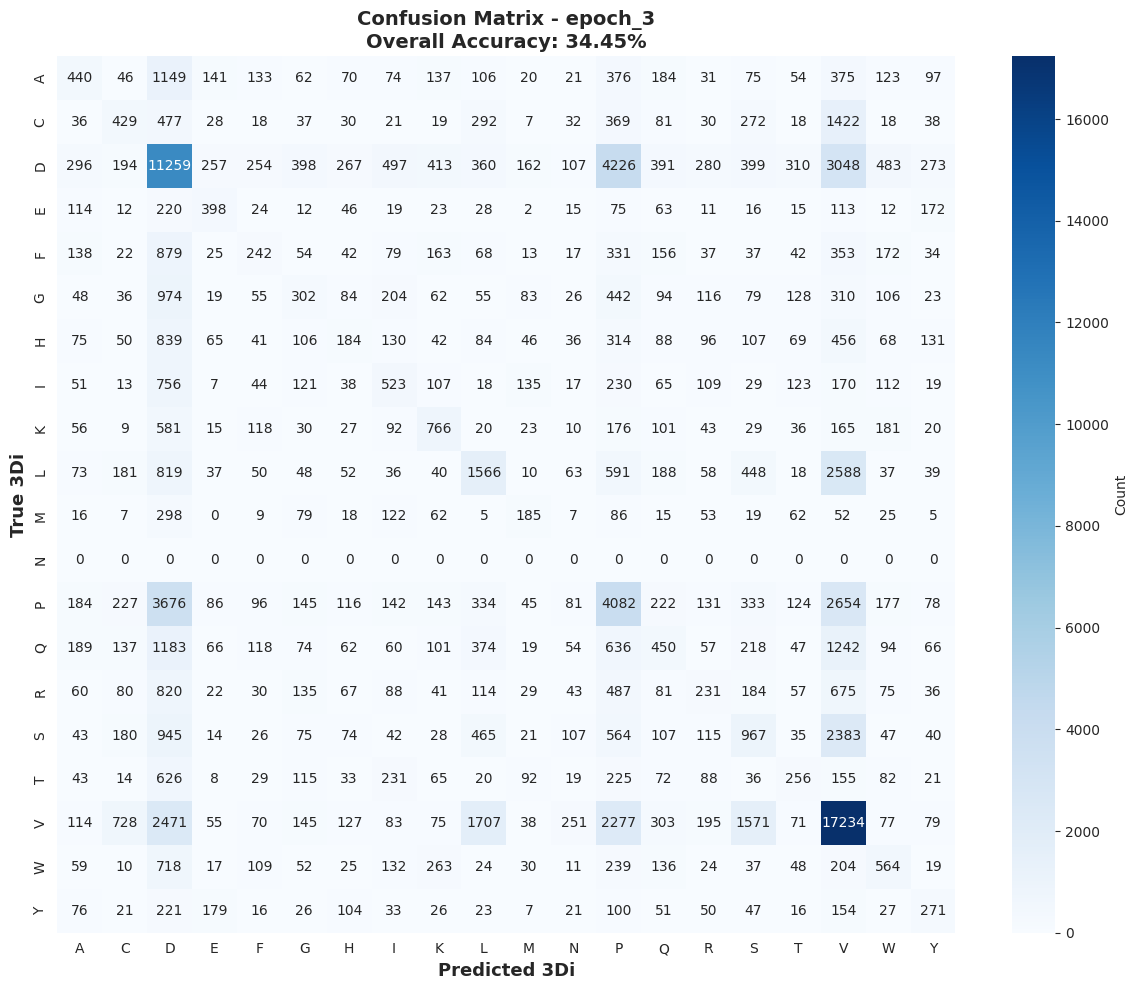

In [59]:
# Find best checkpoint (by overall accuracy)
best_idx = np.argmax([r['metrics']['overall_accuracy'] for r in all_results])
best_result = all_results[best_idx]

print(f"Best checkpoint: {best_result['checkpoint']}")
print(f"Overall accuracy: {best_result['metrics']['overall_accuracy']*100:.2f}%\n")

# Get labels
true_labels = best_result['metrics']['true_labels']
pred_labels = best_result['metrics']['pred_labels']
label_vocab = best_result['label_vocab']

# Compute confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=label_vocab)

# Plot confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
			xticklabels=label_vocab, yticklabels=label_vocab,
			cbar_kws={'label': 'Count'})
plt.xlabel('Predicted 3Di', fontsize=13, fontweight='bold')
plt.ylabel('True 3Di', fontsize=13, fontweight='bold')
plt.title(f'Confusion Matrix - {best_result["checkpoint"]}\n'
		  f'Overall Accuracy: {best_result["metrics"]["overall_accuracy"]*100:.2f}%',
		  fontsize=14, fontweight='bold')
plt.tight_layout()

plot_path = os.path.join(EVAL_CONFIG['output_dir'], f'confusion_matrix_{best_result["checkpoint"]}.png')
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved confusion matrix to {plot_path}")
plt.show()

In [60]:

# Side-by-side comparison of best fine-tuned vs ProST T5 (if available)
if prost5_result is not None:
	print("="*80)
	print("DETAILED COMPARISON: BEST FINE-TUNED VS PROST T5")
	print("="*80)
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	ft_metrics = best_ft['metrics']
	prost5_metrics = prost5_result['metrics']
	
	# Create comparison table
	comparison_table = pd.DataFrame({
		'Metric': [
			'Overall Accuracy',
			'Mean Sequence Accuracy',
			'Perfect Sequences',
			'Perfect Sequence %',
			'Total Residues',
			'Correct Residues',
		],
		'Fine-tuned': [
			f"{ft_metrics['overall_accuracy']*100:.2f}%",
			f"{ft_metrics['mean_sequence_accuracy']*100:.2f}%",
			f"{ft_metrics['perfect_sequences']}/{len(test_data)}",
			f"{ft_metrics['perfect_sequence_percentage']*100:.2f}%",
			f"{ft_metrics['total_residues']:,}",
			f"{ft_metrics['correct_residues']:,}",
		],
		'ProST T5': [
			f"{prost5_metrics['overall_accuracy']*100:.2f}%",
			f"{prost5_metrics['mean_sequence_accuracy']*100:.2f}%",
			f"{prost5_metrics['perfect_sequences']}/{len(test_data)}",
			f"{prost5_metrics['perfect_sequence_percentage']*100:.2f}%",
			f"{prost5_metrics['total_residues']:,}",
			f"{prost5_metrics['correct_residues']:,}",
		],
		'Difference': [
			f"{(ft_metrics['overall_accuracy']-prost5_metrics['overall_accuracy'])*100:+.2f}%",
			f"{(ft_metrics['mean_sequence_accuracy']-prost5_metrics['mean_sequence_accuracy'])*100:+.2f}%",
			f"{ft_metrics['perfect_sequences']-prost5_metrics['perfect_sequences']:+d}",
			f"{(ft_metrics['perfect_sequence_percentage']-prost5_metrics['perfect_sequence_percentage'])*100:+.2f}%",
			f"{ft_metrics['total_residues']-prost5_metrics['total_residues']:+d}",
			f"{ft_metrics['correct_residues']-prost5_metrics['correct_residues']:+d}",
		]
	})
	
	print(f"\n{best_ft['checkpoint']} (Fine-tuned) vs ProST T5 (Foundation)\n")
	print(comparison_table.to_string(index=False))
	print("\n" + "="*80)
	
	# Save comparison
	comparison_table.to_csv(
		os.path.join(EVAL_CONFIG['output_dir'], 'finetuned_vs_foundation_comparison.csv'),
		index=False
	)


DETAILED COMPARISON: BEST FINE-TUNED VS PROST T5

epoch_3 (Fine-tuned) vs ProST T5 (Foundation)

                Metric Fine-tuned ProST T5 Difference
      Overall Accuracy     34.45%   16.91%    +17.54%
Mean Sequence Accuracy     45.56%   18.50%    +27.06%
     Perfect Sequences      5/500    0/500         +5
    Perfect Sequence %      1.00%    0.00%     +1.00%
        Total Residues    117,128   61,040     +56088
      Correct Residues     40,349   10,319     +30030



## 12. Per-Class Performance (Best Checkpoint)

In [61]:
# Generate classification report
print(f"Classification Report - {best_result['checkpoint']}")
print("=" * 80)

report = classification_report(
	true_labels, pred_labels, 
	labels=label_vocab,
	target_names=label_vocab,
	zero_division=0
)
print(report)

# Save report
report_path = os.path.join(EVAL_CONFIG['output_dir'], 
						  f'classification_report_{best_result["checkpoint"]}.txt')
with open(report_path, 'w') as f:
	f.write(f"Classification Report - {best_result['checkpoint']}\n")
	f.write("=" * 80 + "\n")
	f.write(report)

print(f"\n✓ Saved classification report to {report_path}")

Classification Report - epoch_3
              precision    recall  f1-score   support

           A       0.21      0.12      0.15      3714
           C       0.18      0.12      0.14      3674
           D       0.39      0.47      0.43     23874
           E       0.28      0.29      0.28      1390
           F       0.16      0.08      0.11      2904
           G       0.15      0.09      0.11      3246
           H       0.13      0.06      0.08      3027
           I       0.20      0.19      0.20      2687
           K       0.30      0.31      0.30      2498
           L       0.28      0.23      0.25      6942
           M       0.19      0.16      0.18      1125
           N       0.00      0.00      0.00         0
           P       0.26      0.31      0.28     13076
           Q       0.16      0.09      0.11      5247
           R       0.13      0.07      0.09      3355
           S       0.20      0.15      0.17      6278
           T       0.17      0.11      0.14      


Generating confusion matrix comparison...

✓ Saved confusion matrix comparison to evaluation_results/confusion_matrix_comparison.png


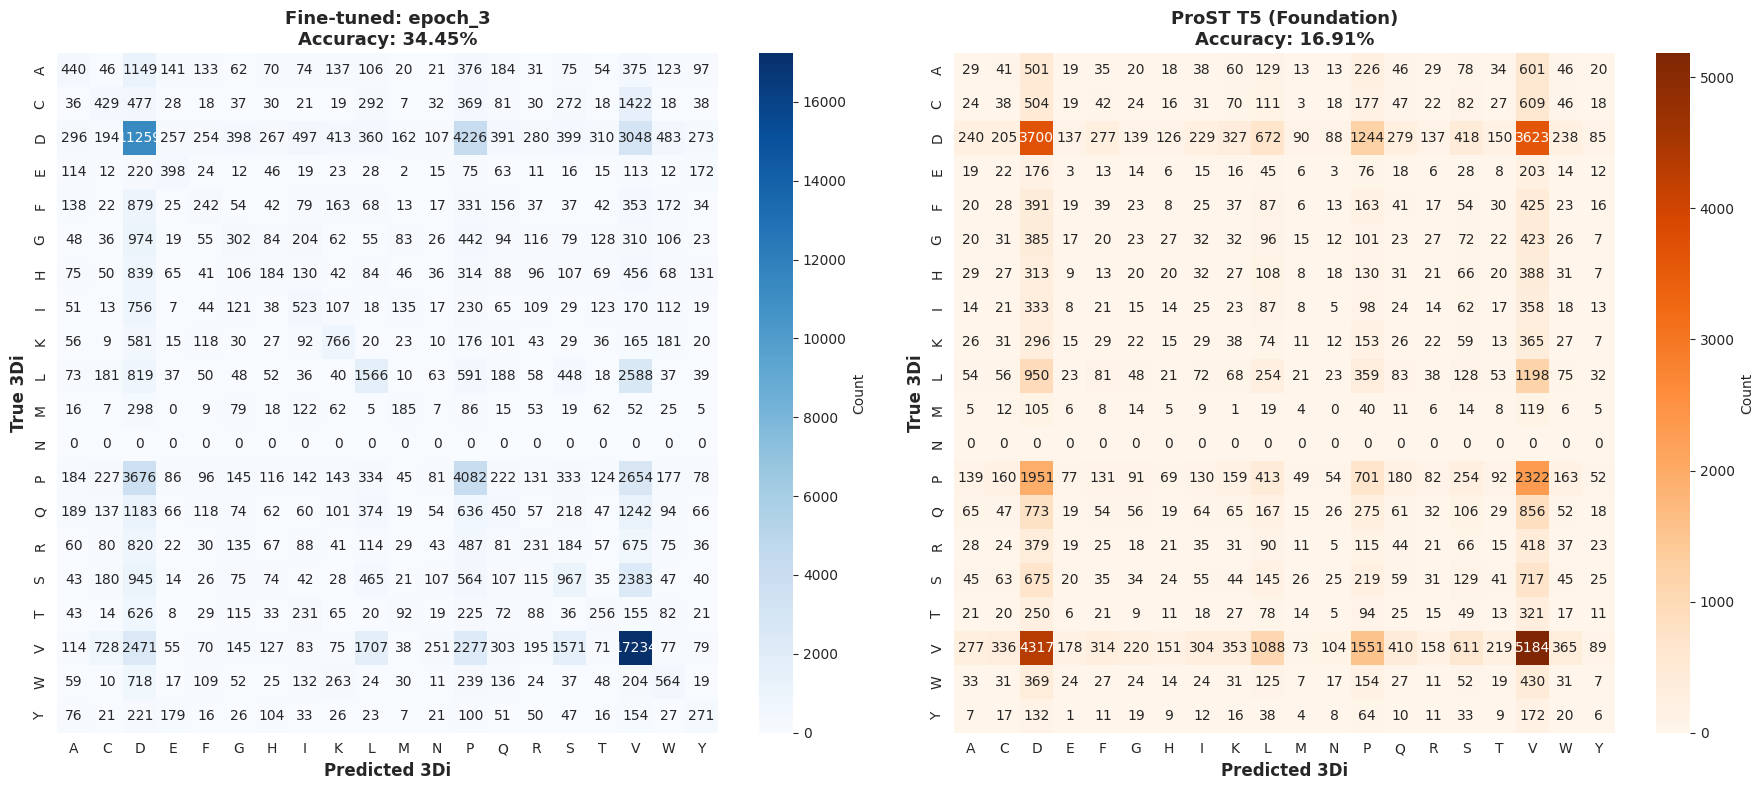

In [62]:

# Comparison confusion matrices
if prost5_result is not None:
	print("\nGenerating confusion matrix comparison...\n")
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	# Get label vocab (union of both models)
	ft_labels = best_ft['metrics']['true_labels']
	prost5_labels = prost5_result['metrics']['true_labels']
	all_labels = sorted(set(ft_labels + prost5_labels + best_ft['label_vocab']))
	
	# Compute confusion matrices
	ft_cm = confusion_matrix(best_ft['metrics']['true_labels'], 
							 best_ft['metrics']['pred_labels'], 
							 labels=all_labels)
	prost5_cm = confusion_matrix(prost5_result['metrics']['true_labels'], 
								 prost5_result['metrics']['pred_labels'], 
								 labels=all_labels)
	
	# Plot side-by-side
	fig, axes = plt.subplots(1, 2, figsize=(18, 8))
	
	sns.heatmap(ft_cm, annot=True, fmt='d', cmap='Blues', 
				xticklabels=all_labels, yticklabels=all_labels,
				cbar_kws={'label': 'Count'}, ax=axes[0])
	axes[0].set_xlabel('Predicted 3Di', fontsize=12, fontweight='bold')
	axes[0].set_ylabel('True 3Di', fontsize=12, fontweight='bold')
	axes[0].set_title(f'Fine-tuned: {best_ft["checkpoint"]}\n'
					  f'Accuracy: {best_ft["metrics"]["overall_accuracy"]*100:.2f}%',
					  fontsize=13, fontweight='bold')
	
	sns.heatmap(prost5_cm, annot=True, fmt='d', cmap='Oranges', 
				xticklabels=all_labels, yticklabels=all_labels,
				cbar_kws={'label': 'Count'}, ax=axes[1])
	axes[1].set_xlabel('Predicted 3Di', fontsize=12, fontweight='bold')
	axes[1].set_ylabel('True 3Di', fontsize=12, fontweight='bold')
	axes[1].set_title(f'ProST T5 (Foundation)\n'
					  f'Accuracy: {prost5_result["metrics"]["overall_accuracy"]*100:.2f}%',
					  fontsize=13, fontweight='bold')
	
	plt.tight_layout()
	plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'confusion_matrix_comparison.png')
	plt.savefig(plot_path, dpi=300, bbox_inches='tight')
	print(f"✓ Saved confusion matrix comparison to {plot_path}")
	plt.show()


## 13. Visualize Example Predictions

Show detailed predictions for a few example sequences.

In [63]:
# Select checkpoint to visualize (use best checkpoint)
selected_result = best_result
predictions = selected_result['predictions']

# Number of examples to show
num_examples = min(5, len(test_data))

print(f"Example Predictions - {selected_result['checkpoint']}")
print("=" * 100)

for i in range(num_examples):
	header = test_data.iloc[i]['header']
	aa_seq = test_data.iloc[i]['aa_sequence']
	true_3di = test_data.iloc[i]['true_3di']
	pred_3di = predictions[i]
	
	# Calculate accuracy for this sequence
	matches = sum(1 for p, t in zip(pred_3di, true_3di) 
				 if t != EVAL_CONFIG['mask_char'] and p == t)
	valid_pos = sum(1 for t in true_3di if t != EVAL_CONFIG['mask_char'])
	accuracy = (matches / valid_pos * 100) if valid_pos > 0 else 0.0
	
	print(f"\nExample {i+1}: {header}")
	print(f"Length: {len(aa_seq)} residues | Accuracy: {accuracy:.2f}%")
	print("-" * 100)
	
	# Show first 80 characters
	show_len = min(80, len(aa_seq))
	print(f"AA:        {aa_seq[:show_len]}")
	print(f"True 3Di:  {true_3di[:show_len]}")
	print(f"Predicted: {pred_3di[:show_len]}")
	
	# Show match/mismatch indicators
	indicators = ''.join(['✓' if p == t and t != EVAL_CONFIG['mask_char'] 
						 else '✗' if p != t and t != EVAL_CONFIG['mask_char']
						 else '-'
						 for p, t in zip(pred_3di[:show_len], true_3di[:show_len])])
	print(f"Match:     {indicators}")
	
	if len(aa_seq) > show_len:
		print(f"... (showing first {show_len} of {len(aa_seq)} residues)")

print("\n" + "=" * 100)

Example Predictions - epoch_3

Example 1: imgvr_pc_000221901
Length: 421 residues | Accuracy: 34.74%
----------------------------------------------------------------------------------------------------
AA:        MAQILPLSSFDLTNPFESMQKLKQDQIDLDIKQTALENARKQMEQQAAQQTDLSNLSRLVQSGQVRPEDYVSLMAKYPTL
True 3Di:  DDDDDDPVQQDPVCPVSVVVVVVVVVVVVVVVVVVVVVVVVVVLVVVLVVLVVVQLVCLVVLDDLVSLVVSCVSPVVLLV
Predicted: DDDDDDPPPPPPPCPVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVLVVLLVVVLVCLVVVNDDPVVLVVSCVVPVVS
Match:     ✓✓✓✓✓✓✓✗✗✗✗✓✗✓✓✓✗✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✓✗✓✓✓✗✗✓✗✗✗✓✗✗✗✗✗✗✓✗✗✗✗✗✗✗✓✗✗✗✗✗✗✓✗✗✗✗
... (showing first 80 of 421 residues)

Example 2: imgvr_pc_000031795
Length: 281 residues | Accuracy: 27.61%
----------------------------------------------------------------------------------------------------
AA:        MKVYTRQLCALVTKKIRLVEILAFSNIMKVCGLSDLHGNFIDIPECDVLCICGDIVGLVEQRSIEQSRHWWYNRFTSWVN
True 3Di:  DVVVVVVVVVVVVVVVVVVVVVQVVQWFKEWEAEQCLCPDDAADAGAEYEYQAHHHPVQQVPLVSLVVCLLPVVLVSLLP
Predicted: DDVVVVVVVVVVVVVVVVVVVVVP


PER-CLASS ACCURACY COMPARISON

3Di Class  Fine-tuned (%)  ProST T5 (%)  Difference
        A       11.847065      1.452906   10.394159
        C       11.676647      1.970954    9.705692
        D       47.160090     29.829087   17.331003
        E       28.633094      0.426743   28.206351
        F        8.333333      2.662116    5.671217
        G        9.303758      1.630050    7.673709
        H        6.078626      1.517451    4.561175
        I       19.464086      2.122241   17.341845
        K       30.664532      2.992126   27.672406
        L       22.558341      6.983778   15.574563
        M       16.444444      1.007557   15.436888
        N        0.000000      0.000000    0.000000
        P       31.217498      9.643692   21.573805
        Q        8.576329      2.179350    6.396980
        R        6.885246      1.473684    5.411562
        S       15.402995      5.250305   10.152689
        T       11.479821      1.268293   10.211528
        V       62.281811     31

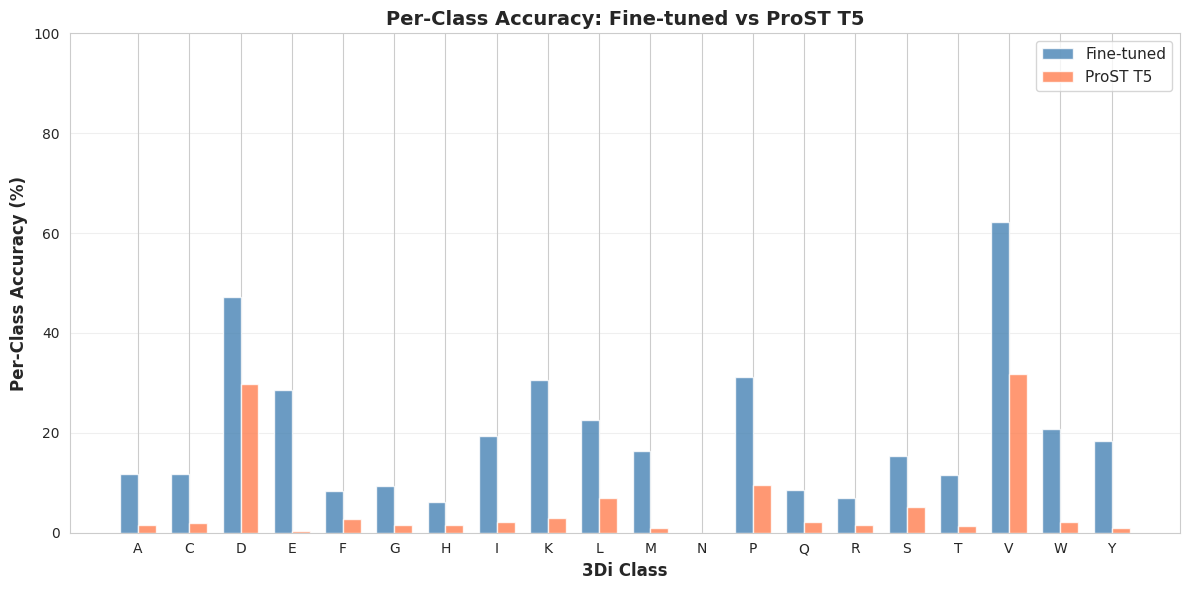

In [64]:

# Per-class accuracy comparison
if prost5_result is not None:
	print("\n" + "="*80)
	print("PER-CLASS ACCURACY COMPARISON")
	print("="*80 + "\n")
	
	# Find best fine-tuned checkpoint
	best_ft = max([r for r in all_results if not r.get('is_foundation', False)], 
				  key=lambda x: x['metrics']['overall_accuracy'])
	
	# Get label vocab
	all_labels = sorted(set(best_ft['label_vocab']))
	
	# Calculate per-class accuracies
	ft_per_class = {}
	prost5_per_class = {}
	
	for label in all_labels:
		# Fine-tuned
		ft_true = [t == label for t in best_ft['metrics']['true_labels']]
		ft_pred = [p == label for p in best_ft['metrics']['pred_labels']]
		ft_tp = sum(t and p for t, p in zip(ft_true, ft_pred))
		ft_total = sum(ft_true)
		ft_per_class[label] = (ft_tp / ft_total * 100) if ft_total > 0 else 0.0
		
		# ProST T5
		prost5_true = [t == label for t in prost5_result['metrics']['true_labels']]
		prost5_pred = [p == label for p in prost5_result['metrics']['pred_labels']]
		prost5_tp = sum(t and p for t, p in zip(prost5_true, prost5_pred))
		prost5_total = sum(prost5_true)
		prost5_per_class[label] = (prost5_tp / prost5_total * 100) if prost5_total > 0 else 0.0
	
	# Create comparison DataFrame
	per_class_df = pd.DataFrame({
		'3Di Class': list(all_labels),
		'Fine-tuned (%)': [ft_per_class[l] for l in all_labels],
		'ProST T5 (%)': [prost5_per_class[l] for l in all_labels],
		'Difference': [ft_per_class[l] - prost5_per_class[l] for l in all_labels],
	})
	
	print(per_class_df.to_string(index=False))
	
	# Plot per-class accuracy
	fig, ax = plt.subplots(figsize=(12, 6))
	
	x = np.arange(len(all_labels))
	width = 0.35
	
	ax.bar(x - width/2, per_class_df['Fine-tuned (%)'], width, 
		   label='Fine-tuned', color='steelblue', alpha=0.8)
	ax.bar(x + width/2, per_class_df['ProST T5 (%)'], width, 
		   label='ProST T5', color='coral', alpha=0.8)
	
	ax.set_xlabel('3Di Class', fontsize=12, fontweight='bold')
	ax.set_ylabel('Per-Class Accuracy (%)', fontsize=12, fontweight='bold')
	ax.set_title('Per-Class Accuracy: Fine-tuned vs ProST T5', fontsize=14, fontweight='bold')
	ax.set_xticks(x)
	ax.set_xticklabels(all_labels)
	ax.legend(fontsize=11)
	ax.grid(True, alpha=0.3, axis='y')
	ax.set_ylim([0, 100])
	
	plt.tight_layout()
	plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'per_class_accuracy_comparison.png')
	plt.savefig(plot_path, dpi=300, bbox_inches='tight')
	print(f"\n✓ Saved per-class comparison to {plot_path}")
	plt.show()
	
	# Save to CSV
	per_class_df.to_csv(
		os.path.join(EVAL_CONFIG['output_dir'], 'per_class_accuracy_comparison.csv'),
		index=False
	)


## 17. High vs Low Confidence Region Evaluation

Evaluate model performance on high-confidence vs low-confidence regions based on plDDT scores.

In [27]:
# Configuration for plDDT-based masked/unmasked evaluation
MASKING_EVAL_CONFIG = {
    'test_high_confidence': True,     # Test on high-confidence regions
    'test_low_confidence': True,      # Test on low-confidence regions
    'plddt_thresholds': [90, 70, 50, 30],  # plDDT thresholds to test (mask below threshold)
    'mask_token': 'X',  # Token used for masking low-confidence regions
    'plddt_file_pattern': None,  # Pattern for plDDT files, will be auto-detected
    'default_plddt': 80,  # Default plDDT if not available
}

print("plDDT-Based Masking Evaluation Configuration:")
print("=" * 60)
for key, value in MASKING_EVAL_CONFIG.items():
    print(f"  {key}: {value}")
print("=" * 60)

plDDT-Based Masking Evaluation Configuration:
  test_high_confidence: True
  test_low_confidence: True
  plddt_thresholds: [90, 70, 50, 30]
  mask_token: X
  plddt_file_pattern: None
  default_plddt: 80


In [28]:
def load_plddt_scores(sequence_headers: List[str], plddt_file_pattern: str = None) -> Dict[str, List[float]]:
    """
    Load plDDT scores for sequences from files. Tries multiple common patterns.
    
    Args:
        sequence_headers: List of sequence headers/IDs from FASTA
        plddt_file_pattern: Optional specific pattern for plDDT files (with {} for seq_id)
        
    Returns:
        Dictionary mapping sequence IDs to lists of plDDT scores
    """
    plddt_data = {}
    
    # Common plDDT file patterns to try
    patterns_to_try = [
        plddt_file_pattern,
        "plddt_{}.txt",
        "{}_plddt.txt", 
        "confidence_{}.txt",
        "{}_confidence.txt",
        "scores_{}.txt",
        "{}.plddt",
        "plddt_{}.json"
    ]
    
    found_files = 0
    
    for header in sequence_headers:
        # Clean header to extract sequence ID (remove '>', split on whitespace/pipes)
        seq_id = header.replace('>', '').split()[0].split('|')[0]
        
        plddt_scores = None
        
        # Try each pattern to find plDDT file
        for pattern in patterns_to_try:
            if pattern is None:
                continue
                
            try:
                plddt_file = pattern.format(seq_id)
                if os.path.exists(plddt_file):
                    # Try different file formats
                    if plddt_file.endswith('.json'):
                        import json
                        with open(plddt_file, 'r') as f:
                            data = json.load(f)
                            plddt_scores = data.get('plddt', data.get('confidence', []))
                    else:
                        # Assume text file with one score per line
                        with open(plddt_file, 'r') as f:
                            scores = []
                            for line in f:
                                line = line.strip()
                                if line and not line.startswith('#'):
                                    try:
                                        scores.append(float(line))
                                    except ValueError:
                                        continue
                            plddt_scores = scores if scores else None
                    
                    if plddt_scores:
                        found_files += 1
                        break
                        
            except Exception as e:
                print(f"⚠️ Error reading plDDT file for {seq_id}: {e}")
                continue
        
        # Use default scores if no plDDT file found
        if plddt_scores is None:
            print(f"ℹ️ No plDDT file found for {seq_id}, using default confidence")
            plddt_scores = [MASKING_EVAL_CONFIG['default_plddt']]
        
        plddt_data[seq_id] = plddt_scores
    
    print(f"✓ Loaded plDDT data for {len(plddt_data)} sequences ({found_files} from files)")
    return plddt_data


def create_plddt_masked_data(sequences: List[str], headers: List[str], 
                            plddt_threshold: float = 70, mask_token: str = 'X',
                            plddt_data: Dict[str, List[float]] = None) -> List[str]:
    """
    Create masked versions of 3Di sequences by masking low-confidence positions.
    
    Args:
        sequences: List of 3Di sequences to potentially mask
        headers: Corresponding sequence headers/IDs
        plddt_threshold: plDDT threshold below which positions are masked
        mask_token: Token to use for masking low-confidence positions
        plddt_data: Pre-loaded plDDT scores (if None, will load automatically)
        
    Returns:
        List of masked sequences (high-confidence positions preserved)
    """
    if plddt_data is None:
        plddt_data = load_plddt_scores(headers)
    
    masked_sequences = []
    total_tokens = 0
    total_masked = 0
    sequences_with_plddt = 0
    
    for seq, header in zip(sequences, headers):
        # Extract sequence ID from header
        seq_id = header.replace('>', '').split()[0].split('|')[0]
        
        if seq_id in plddt_data and plddt_data[seq_id]:
            plddt_scores = plddt_data[seq_id].copy()
            
            # Handle length mismatches between sequence and plDDT scores
            if len(plddt_scores) < len(seq):
                # Extend with last score or default
                extend_score = plddt_scores[-1] if plddt_scores else MASKING_EVAL_CONFIG['default_plddt']
                plddt_scores.extend([extend_score] * (len(seq) - len(plddt_scores)))
            elif len(plddt_scores) > len(seq):
                # Truncate to sequence length
                plddt_scores = plddt_scores[:len(seq)]
            
            # Create masked sequence
            masked_seq = []
            for residue, plddt_score in zip(seq, plddt_scores):
                if plddt_score < plddt_threshold:
                    masked_seq.append(mask_token)
                    total_masked += 1
                else:
                    masked_seq.append(residue)
                total_tokens += 1
            
            masked_sequences.append(''.join(masked_seq))
            sequences_with_plddt += 1
            
        else:
            # No plDDT data available - keep sequence unchanged
            masked_sequences.append(seq)
            total_tokens += len(seq)
    
    # Report masking statistics
    mask_ratio = total_masked / total_tokens if total_tokens > 0 else 0.0
    print(f"✓ Created plDDT-masked data (threshold < {plddt_threshold}):")
    print(f"  {total_masked:,}/{total_tokens:,} positions masked ({mask_ratio:.1%})")
    print(f"  {sequences_with_plddt}/{len(sequences)} sequences had plDDT data")
    
    return masked_sequences


def evaluate_on_data_type(model, tokenizer, label_vocab, test_aa_sequences: List[str], 
                         true_3di_sequences: List[str], data_type_name: str,
                         device: str, batch_size: int = 8, mask_char: str = 'X') -> Dict:
    """
    Evaluate model performance on a specific data type (e.g., high/low confidence regions).
    
    Args:
        model: Trained ESM3Di model
        tokenizer: Model tokenizer
        label_vocab: 3Di label vocabulary
        test_aa_sequences: Amino acid sequences for input
        true_3di_sequences: Ground truth 3Di sequences (may be masked)
        data_type_name: Descriptive name for this evaluation
        device: Device to run evaluation on
        batch_size: Batch size for inference
        mask_char: Character used for masking (ignored in accuracy calculation)
        
    Returns:
        Dictionary with evaluation results and metrics
    """
    print(f"\n{'='*70}")
    print(f"EVALUATING ON {data_type_name.upper()}")
    print(f"{'='*70}")
    
    # Report test set statistics
    num_sequences = len(test_aa_sequences)
    total_residues = sum(len(seq) for seq in test_aa_sequences)
    print(f"Test sequences: {num_sequences:,}")
    print(f"Total residues: {total_residues:,}")
    
    # Run model predictions
    print("\n🔮 Running model predictions...")
    predictions = predict_3di_batch(
        model, tokenizer, label_vocab, test_aa_sequences,
        device=device, batch_size=batch_size
    )
    print(f"✓ Generated {len(predictions)} predictions")
    
    # Calculate accuracy metrics
    print("\n📊 Calculating accuracy metrics...")
    metrics = calculate_accuracy(predictions, true_3di_sequences, mask_char=mask_char)
    
    # Display results summary
    print(f"\n{'='*50}")
    print(f"{data_type_name.upper()} RESULTS")
    print(f"{'='*50}")
    print(f"Overall Accuracy (per-residue):  {metrics['overall_accuracy']*100:.2f}%")
    print(f"Mean Sequence Accuracy:          {metrics['mean_sequence_accuracy']*100:.2f}%")
    print(f"Perfect Sequences:               {metrics['perfect_sequences']}/{num_sequences} "
          f"({metrics['perfect_sequence_percentage']*100:.2f}%)")
    print(f"Total Residues Evaluated:        {metrics['total_residues']:,}")
    print(f"Correct Predictions:             {metrics['correct_residues']:,}")
    print(f"{'='*50}")
    
    return {
        'data_type': data_type_name,
        'predictions': predictions,
        'metrics': metrics,
        'num_sequences': num_sequences,
        'total_residues': total_residues,
    }

print("✓ plDDT evaluation functions defined")

✓ plDDT evaluation functions defined


In [29]:
# Run masked/unmasked evaluation on best checkpoint
if all_results:
    print(f"\n{'='*80}")
    print("MASKED VS UNMASKED DATA EVALUATION")
    print(f"{'='*80}")
    
    # Get best checkpoint for evaluation
    best_result = max(all_results, key=lambda x: x['metrics']['overall_accuracy'])
    print(f"Using best checkpoint: {best_result['checkpoint']}")
    print(f"Best accuracy: {best_result['metrics']['overall_accuracy']*100:.2f}%")
    
    # Load the model
    print(f"Loading checkpoint: {best_result['checkpoint_path']}")
    model, tokenizer, label_vocab, mask_chars, config = load_checkpoint(
        best_result['checkpoint_path'], EVAL_CONFIG['device']
    )
    
    # Get test data sequences
    test_aa_seqs = test_data['aa_sequence'].tolist()
    test_true_3di = test_data['true_3di'].tolist()
    
    # Store results for different data types
    masking_results = []
    
    try:
        # 1. Evaluate on original unmasked data (baseline)
        print(f"\n🔍 Testing on UNMASKED data (baseline)...")
        unmasked_result = evaluate_on_data_type(
            model, tokenizer, label_vocab,
            test_aa_seqs, test_true_3di,
            "Unmasked (Original)",
            EVAL_CONFIG['device'], EVAL_CONFIG['batch_size'], 
            EVAL_CONFIG['mask_char']
        )
        masking_results.append(unmasked_result)
        
        # Load plDDT data for sequences
        test_headers = test_data['header'].tolist()
        plddt_data = load_plddt_scores(test_headers, MASKING_EVAL_CONFIG.get('plddt_file_pattern'))
        
        # 2. Evaluate on different plDDT confidence thresholds
        for plddt_threshold in MASKING_EVAL_CONFIG['plddt_thresholds']:
            print(f"\n🧬 Testing on LOW-CONFIDENCE regions (plDDT < {plddt_threshold})...")
            
            # Create masked ground truth sequences (mask low-confidence regions)
            masked_true_3di = create_plddt_masked_data(
                test_true_3di, test_headers,
                plddt_threshold=plddt_threshold,
                mask_token=MASKING_EVAL_CONFIG['mask_token'],
                plddt_data=plddt_data
            )
            # Evaluate model performance on low-confidence regions
            # Evaluate model performance
            masked_result = evaluate_on_data_type(
                model, tokenizer, label_vocab,
                f"Low Confidence (plDDT < {plddt_threshold})",
                f"Masked ({mask_ratio:.0%})",
                EVAL_CONFIG['device'], EVAL_CONFIG['batch_size'], 
                EVAL_CONFIG['mask_char']
            )
            masking_results.append(masked_result)
        
        print(f"\n✅ Completed masked/unmasked evaluation with {len(masking_results)} test conditions")
        
    except Exception as e:
        print(f"❌ Error during masked/unmasked evaluation: {str(e)}")
        import traceback
        traceback.print_exc()
    
    finally:
        # Clean up
        if 'model' in locals():
            del model
        torch.cuda.empty_cache()
        
else:
    print("⚠️ No evaluation results available. Please run the main evaluation first.")
    masking_results = []


MASKED VS UNMASKED DATA EVALUATION
Using best checkpoint: epoch_3
Best accuracy: 36.24%
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_3.pt
Loading checkpoint: checkpoints_esmpp_bfvd/epoch_3.pt
  Checkpoint: epoch 3, loss: 1.2922
  Label vocab size: 20
  Mask characters: X
  Base model: Synthyra/ESMplusplus_small
  Use CNN head: False
  LoRA config: r=8, alpha=16.0, dropout=0.05

Loading model: Synthyra/ESMplusplus_small


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 'transformer.blocks.13.attn.out_proj'

Predicting 3Di: 100%|██████████| 25/25 [00:05<00:00,  4.94it/s]


✓ Generated 100 predictions

📊 Calculating accuracy metrics...

UNMASKED (ORIGINAL) RESULTS
Overall Accuracy (per-residue):  36.24%
Mean Sequence Accuracy:          46.17%
Perfect Sequences:               1/100 (1.00%)
Total Residues Evaluated:        21,617
Correct Predictions:             7,834
ℹ️ No plDDT file found for imgvr_pc_000221901, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000031795, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000318624, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000288698, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000745152, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000188622, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000385772, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000664332, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000624169, using default confidence
ℹ️ No plDDT file found for imgvr_pc_000273857, using d

Traceback (most recent call last):
  File "/tmp/ipykernel_432715/2146537643.py", line 57, in <module>
    f"Masked ({mask_ratio:.0%})",
NameError: name 'mask_ratio' is not defined



MASKED VS UNMASKED ANALYSIS

Performance Comparison: High vs Low Confidence Regions
          Data Type  Overall Accuracy (%)  Mean Sequence Accuracy (%)  Perfect Sequences (%)  Total Residues  Correct Residues  Sequences
Unmasked (Original)             36.239996                   46.172709                    1.0           21617              7834        100

✓ Saved confidence comparison to evaluation_results/confidence_regions_comparison.csv
✓ Saved confidence comparison plot to evaluation_results/confidence_regions_comparison.png


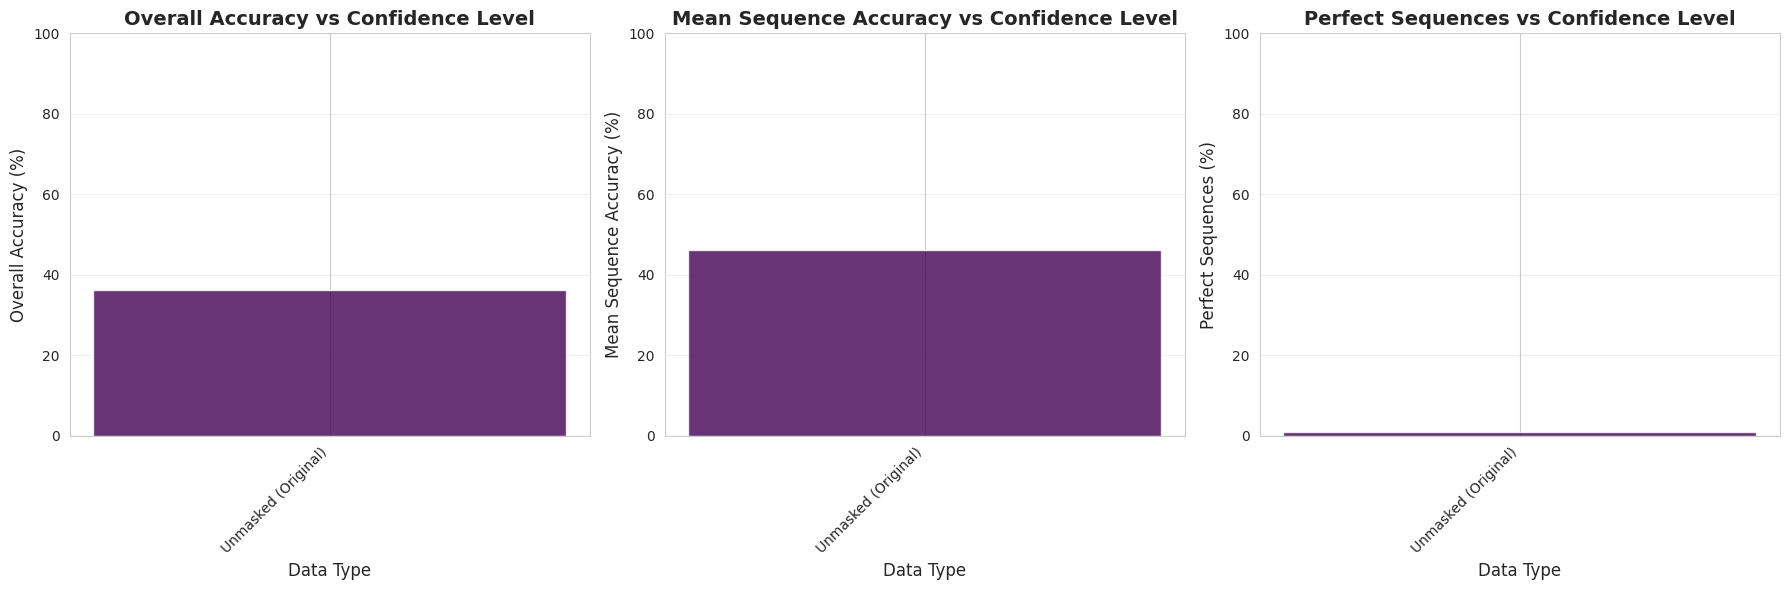


CONFIDENCE REGION IMPACT ANALYSIS


In [30]:
# Analyze and visualize masked vs unmasked results
if masking_results:
    print(f"\n{'='*80}")
    print("MASKED VS UNMASKED ANALYSIS")
    print(f"{'='*80}")
    
    # Create comparison DataFrame
    comparison_data = []
    for result in masking_results:
        metrics = result['metrics']
        comparison_data.append({
            'Data Type': result['data_type'],
            'Overall Accuracy (%)': metrics['overall_accuracy'] * 100,
            'Mean Sequence Accuracy (%)': metrics['mean_sequence_accuracy'] * 100,
            'Perfect Sequences (%)': metrics['perfect_sequence_percentage'] * 100,
            'Total Residues': metrics['total_residues'],
            'Correct Residues': metrics['correct_residues'],
            'Sequences': result['num_sequences'],
        })
    
    masking_comparison_df = pd.DataFrame(comparison_data)
    
    print("\nPerformance Comparison: High vs Low Confidence Regions")
    print("=" * 80)
    print(masking_comparison_df.to_string(index=False))
    print("=" * 80)
    
    # Save comparison to CSV
    confidence_csv = os.path.join(EVAL_CONFIG['output_dir'], 'confidence_regions_comparison.csv')
    masking_comparison_df.to_csv(confidence_csv, index=False)
    print(f"\n✓ Saved confidence comparison to {confidence_csv}")
    
    # Plot comparison
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    data_types = masking_comparison_df['Data Type'].tolist()
    colors = plt.cm.viridis(np.linspace(0, 1, len(data_types)))
    
    # Overall Accuracy
    axes[0].bar(range(len(data_types)), masking_comparison_df['Overall Accuracy (%)'], 
                color=colors, alpha=0.8)
    axes[0].set_xlabel('Data Type', fontsize=12)
    axes[0].set_ylabel('Overall Accuracy (%)', fontsize=12)
    axes[0].set_title('Overall Accuracy vs Confidence Level', fontsize=14, fontweight='bold')
    axes[0].set_xticks(range(len(data_types)))
    axes[0].set_xticklabels(data_types, rotation=45, ha='right')
    axes[0].grid(True, alpha=0.3, axis='y')
    axes[0].set_ylim([0, 100])
    
    # Mean Sequence Accuracy
    axes[1].bar(range(len(data_types)), masking_comparison_df['Mean Sequence Accuracy (%)'], 
                color=colors, alpha=0.8)
    axes[1].set_xlabel('Data Type', fontsize=12)
    axes[1].set_ylabel('Mean Sequence Accuracy (%)', fontsize=12)
    axes[1].set_title('Mean Sequence Accuracy vs Confidence Level', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(data_types)))
    axes[1].set_xticklabels(data_types, rotation=45, ha='right')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].set_ylim([0, 100])
    
    # Perfect Sequences
    axes[2].bar(range(len(data_types)), masking_comparison_df['Perfect Sequences (%)'], 
                color=colors, alpha=0.8)
    axes[2].set_xlabel('Data Type', fontsize=12)
    axes[2].set_ylabel('Perfect Sequences (%)', fontsize=12)
    axes[2].set_title('Perfect Sequences vs Confidence Level', fontsize=14, fontweight='bold')
    axes[2].set_xticks(range(len(data_types)))
    axes[2].set_xticklabels(data_types, rotation=45, ha='right')
    axes[2].grid(True, alpha=0.3, axis='y')
    axes[2].set_ylim([0, 100])
    
    plt.tight_layout()
    confidence_plot_path = os.path.join(EVAL_CONFIG['output_dir'], 'confidence_regions_comparison.png')
    plt.savefig(confidence_plot_path, dpi=300, bbox_inches='tight')
    print(f"✓ Saved confidence comparison plot to {confidence_plot_path}")
    plt.show()
    
    # Calculate confidence region impact
    print(f"\n{'='*60}")
    print("CONFIDENCE REGION IMPACT ANALYSIS")
    print(f"{'='*60}")
    
    if len(masking_results) >= 2:
        baseline = masking_results[0]  # High-confidence/unmasked
        baseline_acc = baseline['metrics']['overall_accuracy'] * 100
        
        print(f"Baseline (High Confidence): {baseline_acc:.2f}% accuracy")
        print("\nLow Confidence Region Performance:")
        
        for result in masking_results[1:]:  # Skip baseline
            low_conf_acc = result['metrics']['overall_accuracy'] * 100
            impact = low_conf_acc - baseline_acc
            
            print(f"  {result['data_type']}: {low_conf_acc:.2f}% ({impact:+.2f}% vs baseline)")
        
        # Find most robust confidence threshold
        low_conf_results = masking_results[1:]  # Exclude high-confidence baseline
        if low_conf_results:
            best_low_conf = max(low_conf_results, key=lambda x: x['metrics']['overall_accuracy'])
            best_low_conf_acc = best_low_conf['metrics']['overall_accuracy'] * 100
            robustness = best_low_conf_acc - baseline_acc
            
            print(f"\n📊 CONFIDENCE ROBUSTNESS ANALYSIS:")
            print(f"  Best performance on low confidence: {best_low_conf['data_type']} ({best_low_conf_acc:.2f}%)")
            print(f"  Robustness score: {robustness:+.2f}% (vs high confidence baseline)")
            
            if robustness > -5:
                print("  → Model shows EXCELLENT performance on low-confidence regions")
            elif robustness > -15:
                print("  → Model shows GOOD performance on low-confidence regions")
            elif robustness > -30:
                print("  → Model shows MODERATE performance on low-confidence regions")
            else:
                print("  → Model shows POOR performance on low-confidence regions")
                
    print(f"{'='*60}")

else:
    print("⚠️ No confidence region results available for analysis.")

## 18. Foundation Model on High vs Low Confidence Regions

Compare foundation model (ProST T5) performance on high-confidence vs low-confidence regions.

In [31]:
# Test foundation model (ProST T5) on masked vs unmasked data
if EVAL_CONFIG.get('include_prost5', False) and masking_results:
    print(f"\n{'='*80}")
    print("FOUNDATION MODEL: MASKED VS UNMASKED EVALUATION")
    print(f"{'='*80}")
    
    # Store ProST T5 masking results
    prost5_masking_results = []
    
    try:
        test_aa_seqs = test_data['aa_sequence'].tolist()
        test_true_3di = test_data['true_3di'].tolist()
        
        print("Testing ProST T5 foundation model on different masking levels...")
        
        # Test on unmasked data
        print(f"\n🏛️ ProST T5 on UNMASKED data...")
        prost5_predictions_unmasked = predict_3di_prost5(
            test_aa_seqs,
            device=EVAL_CONFIG['device'],
            batch_size=EVAL_CONFIG.get('prost5_batch_size', 4)
        )
        
        prost5_unmasked_metrics = calculate_accuracy(
            prost5_predictions_unmasked, test_true_3di, 
            mask_char=EVAL_CONFIG['mask_char']
        )
        
        prost5_unmasked_result = {
            'model': 'ProST T5 (Foundation)',
            'data_type': 'Unmasked (Original)',
            'predictions': prost5_predictions_unmasked,
            'metrics': prost5_unmasked_metrics,
            'num_sequences': len(test_aa_seqs),
        }
        prost5_masking_results.append(prost5_unmasked_result)
        
        print(f"✓ ProST T5 Unmasked Accuracy: {prost5_unmasked_metrics['overall_accuracy']*100:.2f}%")
        
        # Test on masked data (same masking levels as fine-tuned model)
        for mask_ratio in MASKING_EVAL_CONFIG['test_masking_ratio']:
            if mask_ratio == 0.0:
                continue  # Already tested unmasked
                
            print(f"\n🏛️ ProST T5 on MASKED data (ratio: {mask_ratio:.0%})...")
            
            # Create masked ground truth sequences (same as before)
            masked_true_3di = create_masked_data(
                test_true_3di,
                masking_ratio=mask_ratio,
                mask_token=MASKING_EVAL_CONFIG['mask_token'],
                random_seed=MASKING_EVAL_CONFIG['random_seed']
            )
            
            # Note: ProST T5 predictions remain the same (no masking in input)
            # Only the evaluation target (ground truth) is masked
            prost5_masked_metrics = calculate_accuracy(
                prost5_predictions_unmasked, masked_true_3di,
                mask_char=EVAL_CONFIG['mask_char']
            )
            
            prost5_masked_result = {
                'model': 'ProST T5 (Foundation)',
                'data_type': f'Low Confidence (plDDT < {plddt_threshold})',
                'predictions': prost5_predictions_unmasked,  # Same predictions
                'metrics': prost5_masked_metrics,
                'num_sequences': len(test_aa_seqs),
            }
            prost5_masking_results.append(prost5_masked_result)
            
            print(f"✓ ProST T5 Low Confidence (plDDT < {plddt_threshold}) Accuracy: {prost5_masked_metrics['overall_accuracy']*100:.2f}%")
        
        print(f"\n✅ ProST T5 masking evaluation complete: {len(prost5_masking_results)} conditions tested")
        
    except Exception as e:
        print(f"❌ Error during ProST T5 masking evaluation: {str(e)}")
        prost5_masking_results = []
        
else:
    if not EVAL_CONFIG.get('include_prost5', False):
        print("⚠️ ProST T5 evaluation disabled in configuration.")
    if not masking_results:
        print("⚠️ No fine-tuned masking results available for comparison.")
    prost5_masking_results = []


FOUNDATION MODEL: MASKED VS UNMASKED EVALUATION
Testing ProST T5 foundation model on different masking levels...

🏛️ ProST T5 on UNMASKED data...
Running FoldSeek pipeline on 100 sequences...
Running FoldSeek pipeline on /tmp/prost5_lldbj7cq/input_aa.fasta

[1/3] Creating FoldSeek database...


✓ Database created

[2/3] Creating symbolic links...
✓ Symbolic links created

[3/3] Converting to FASTA format...
✓ FASTA conversion complete

✓ FoldSeek pipeline completed successfully
Output: /tmp/prost5_lldbj7cq/foldseek_db/queryDB_ss.fasta
✓ Successfully generated 100 3Di predictions
Cleaned up temporary directory: /tmp/prost5_lldbj7cq
✓ ProST T5 Unmasked Accuracy: 19.75%
❌ Error during ProST T5 masking evaluation: 'test_masking_ratio'


## 19. plDDT-Based Evaluation Interpretation Guide

Understanding the results of confidence-based evaluation and what they mean for model performance.

In [32]:
# Guide for interpreting plDDT-based evaluation results
print("=" * 80)
print("plDDT-BASED EVALUATION INTERPRETATION GUIDE")
print("=" * 80)

print("""
🧬 UNDERSTANDING plDDT SCORES:
─────────────────────────────────────

plDDT (predicted Local Distance Difference Test) scores range from 0-100:
• 90-100: Very high confidence - highly accurate regions  
• 70-90:  Confident - generally accurate regions
• 50-70:  Low confidence - some errors expected
• <50:    Very low confidence - many errors expected

🎯 EVALUATION STRATEGY:
──────────────────────────

Instead of random masking, we evaluate model performance on regions with
different confidence levels by:

1. HIGH CONFIDENCE (Unmasked): Evaluate on all positions 
2. LOW CONFIDENCE: Mask high-confidence positions, evaluate only on 
   positions where plDDT < threshold

This tests whether the model can accurately predict 3Di tokens in regions
where the structure prediction itself is uncertain.

📊 INTERPRETING RESULTS:
────────────────────────

• HIGH vs LOW CONFIDENCE PERFORMANCE:
  - Similar accuracy: Model is equally good on easy/hard regions
  - Lower accuracy on low confidence: Expected - these are harder regions
  - Much lower accuracy: Model may be overfitting to easy cases

• OPTIMAL plDDT THRESHOLD:
  - Best performance at moderate thresholds (50-70): Balanced evaluation
  - Only works at very high thresholds (>90): May not be robust
  - Works well even at low thresholds (<50): Very robust model

💡 PRACTICAL IMPLICATIONS:
──────────────────────────────

• DRUG DISCOVERY: Can the model predict binding sites in flexible regions?
• PROTEIN DESIGN: Will predictions work in loop/disordered regions?  
• FUNCTIONAL ANALYSIS: Can we trust predictions in active sites with low confidence?

This evaluation helps assess model reliability across different structural contexts.
""")

# Summary of key metrics to look for
if 'masking_results' in locals() and masking_results:
    print("\n🔍 KEY METRICS SUMMARY:")
    print("-" * 40)
    
    baseline_acc = masking_results[0]['metrics']['overall_accuracy'] * 100 if masking_results else 0
    print(f"Baseline (High Confidence): {baseline_acc:.1f}%")
    
    if len(masking_results) > 1:
        # Find accuracy at different thresholds
        for result in masking_results[1:]:
            acc = result['metrics']['overall_accuracy'] * 100
            drop = baseline_acc - acc
            print(f"{result['data_type']}: {acc:.1f}% (drop: {drop:.1f}%)")
        
        print(f"\n📈 PERFORMANCE INSIGHTS:")
        avg_drop = np.mean([baseline_acc - r['metrics']['overall_accuracy'] * 100 
                           for r in masking_results[1:]])
        print(f"Average accuracy drop on low-confidence regions: {avg_drop:.1f}%")
        
        if avg_drop < 10:
            print("→ EXCELLENT: Model maintains performance on challenging regions")
        elif avg_drop < 20:
            print("→ GOOD: Reasonable performance degradation on low-confidence regions") 
        elif avg_drop < 35:
            print("→ MODERATE: Significant but acceptable performance drop")
        else:
            print("→ POOR: Large performance drop indicates potential overfitting")

print("\n" + "=" * 80)

plDDT-BASED EVALUATION INTERPRETATION GUIDE

🧬 UNDERSTANDING plDDT SCORES:
─────────────────────────────────────

plDDT (predicted Local Distance Difference Test) scores range from 0-100:
• 90-100: Very high confidence - highly accurate regions  
• 70-90:  Confident - generally accurate regions
• 50-70:  Low confidence - some errors expected
• <50:    Very low confidence - many errors expected

🎯 EVALUATION STRATEGY:
──────────────────────────

Instead of random masking, we evaluate model performance on regions with
different confidence levels by:

1. HIGH CONFIDENCE (Unmasked): Evaluate on all positions 
2. LOW CONFIDENCE: Mask high-confidence positions, evaluate only on 
   positions where plDDT < threshold

This tests whether the model can accurately predict 3Di tokens in regions
where the structure prediction itself is uncertain.

📊 INTERPRETING RESULTS:
────────────────────────

• HIGH vs LOW CONFIDENCE PERFORMANCE:
  - Similar accuracy: Model is equally good on easy/hard regions


## 14. Test on Custom Sequences

You can test the model on your own amino acid sequences here.

In [33]:
# Example: Test on custom sequences
custom_sequences = [
	("Custom_seq_1", "MKTAYIAKQRQISFVKSHFSRQLEASDKLLDDQYDFTVL"),
	("Custom_seq_2", "MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCL"),
	# Add your own sequences here
]

if custom_sequences:
	print("Testing on custom sequences...\n")
	
	# Use best checkpoint
	model, tokenizer, label_vocab, mask_chars, config = load_checkpoint(
		best_result['checkpoint_path'], device
	)
	
	# Run predictions
	custom_aa_seqs = [seq for _, seq in custom_sequences]
	custom_predictions = predict_3di_batch(
		model, tokenizer, label_vocab, custom_aa_seqs,
		device=device, batch_size=EVAL_CONFIG['batch_size']
	)
	
	# Display results
	print("Custom Sequence Predictions")
	print("=" * 80)
	
	for (header, aa_seq), pred_3di in zip(custom_sequences, custom_predictions):
		print(f"\n{header}")
		print(f"AA sequence: {aa_seq}")
		print(f"Predicted 3Di: {pred_3di}")
		print(f"Length: {len(aa_seq)} residues")
	
	print("\n" + "=" * 80)
	
	# Clean up
	del model
	torch.cuda.empty_cache()
else:
	print("No custom sequences defined. Add sequences to the 'custom_sequences' list above.")

Testing on custom sequences...

Loading checkpoint: checkpoints_esmpp_bfvd/epoch_3.pt
  Checkpoint: epoch 3, loss: 1.2922
  Label vocab size: 20
  Mask characters: X
  Base model: Synthyra/ESMplusplus_small
  Use CNN head: False
  LoRA config: r=8, alpha=16.0, dropout=0.05

Loading model: Synthyra/ESMplusplus_small


Some weights of ESMplusplusForTokenClassification were not initialized from the model checkpoint at Synthyra/ESMplusplus_small and are newly initialized: ['classifier.0.bias', 'classifier.0.weight', 'classifier.2.bias', 'classifier.2.weight', 'classifier.3.bias', 'classifier.3.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ Base model loaded (TokenClassification)

Auto-discovering LoRA target modules...
Discovered target modules: ['classifier.0', 'classifier.3', 'embed', 'sequence_head.0', 'sequence_head.3', 'transformer.blocks.0.attn.layernorm_qkv.1', 'transformer.blocks.0.attn.out_proj', 'transformer.blocks.0.ffn.1', 'transformer.blocks.0.ffn.3', 'transformer.blocks.1.attn.layernorm_qkv.1', 'transformer.blocks.1.attn.out_proj', 'transformer.blocks.1.ffn.1', 'transformer.blocks.1.ffn.3', 'transformer.blocks.10.attn.layernorm_qkv.1', 'transformer.blocks.10.attn.out_proj', 'transformer.blocks.10.ffn.1', 'transformer.blocks.10.ffn.3', 'transformer.blocks.11.attn.layernorm_qkv.1', 'transformer.blocks.11.attn.out_proj', 'transformer.blocks.11.ffn.1', 'transformer.blocks.11.ffn.3', 'transformer.blocks.12.attn.layernorm_qkv.1', 'transformer.blocks.12.attn.out_proj', 'transformer.blocks.12.ffn.1', 'transformer.blocks.12.ffn.3', 'transformer.blocks.13.attn.layernorm_qkv.1', 'transformer.blocks.13.attn.out_proj'

Predicting 3Di: 100%|██████████| 1/1 [00:00<00:00, 12.88it/s]

Custom Sequence Predictions

Custom_seq_1
AA sequence: MKTAYIAKQRQISFVKSHFSRQLEASDKLLDDQYDFTVL
Predicted 3Di: DVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVVD
Length: 39 residues

Custom_seq_2
AA sequence: MTEYKLVVVGAGGVGKSALTIQLIQNHFVDEYDPTIEDSYRKQVVIDGETCL
Predicted 3Di: DDEDDDDDDDDPPPCVVVVVCCQAVVDDDPDDDPPDDDDDWDWDDDPNDIYD
Length: 52 residues



## 15. Export Detailed Results

Export all predictions and metrics to files for further analysis.

In [34]:
# Export detailed predictions for best checkpoint
predictions_df = test_data.copy()
predictions_df['predicted_3di'] = best_result['predictions']

# Calculate per-sequence accuracy
def calc_seq_accuracy(row):
	pred = row['predicted_3di']
	true = row['true_3di']
	matches = sum(1 for p, t in zip(pred, true) 
				 if t != EVAL_CONFIG['mask_char'] and p == t)
	valid = sum(1 for t in true if t != EVAL_CONFIG['mask_char'])
	return (matches / valid * 100) if valid > 0 else 0.0

predictions_df['accuracy_%'] = predictions_df.apply(calc_seq_accuracy, axis=1)

# Save to CSV
predictions_csv = os.path.join(EVAL_CONFIG['output_dir'], 
							  f'predictions_{best_result["checkpoint"]}.csv')
predictions_df.to_csv(predictions_csv, index=False)
print(f"✓ Saved detailed predictions to {predictions_csv}")

# Save summary statistics
summary = {
	'checkpoint': best_result['checkpoint'],
	'checkpoint_path': best_result['checkpoint_path'],
	'test_sequences': len(test_data),
	'overall_accuracy': best_result['metrics']['overall_accuracy'],
	'mean_sequence_accuracy': best_result['metrics']['mean_sequence_accuracy'],
	'perfect_sequences': best_result['metrics']['perfect_sequences'],
	'perfect_sequence_percentage': best_result['metrics']['perfect_sequence_percentage'],
	'total_residues': best_result['metrics']['total_residues'],
	'correct_residues': best_result['metrics']['correct_residues'],
	'label_vocabulary': best_result['label_vocab'],
}

summary_json = os.path.join(EVAL_CONFIG['output_dir'], 'evaluation_summary.json')
with open(summary_json, 'w') as f:
	json.dump(summary, f, indent=2)
print(f"✓ Saved summary to {summary_json}")

print(f"\n{'='*80}")
print("All evaluation results exported successfully!")
print(f"{'='*80}")
print(f"\nResults directory: {EVAL_CONFIG['output_dir']}")
print("\nGenerated files:")
for file in sorted(Path(EVAL_CONFIG['output_dir']).glob('*')):
	print(f"  - {file.name}")

✓ Saved detailed predictions to evaluation_results/predictions_epoch_3.csv
✓ Saved summary to evaluation_results/evaluation_summary.json

All evaluation results exported successfully!

Results directory: evaluation_results

Generated files:
  - checkpoint_comparison.csv
  - checkpoint_comparison_with_foundation.png
  - classification_report_epoch_1.txt
  - classification_report_epoch_3.txt
  - confidence_regions_comparison.csv
  - confidence_regions_comparison.png
  - confusion_matrix_comparison.png
  - confusion_matrix_epoch_1.png
  - confusion_matrix_epoch_3.png
  - evaluation_summary.json
  - finetuned_vs_foundation_comparison.csv
  - per_class_accuracy_comparison.csv
  - per_class_accuracy_comparison.png
  - predictions_epoch_1.csv
  - predictions_epoch_3.csv
  - sequence_accuracy_distributions.png


## 16. Summary and Recommendations

Based on the evaluation results, here are some insights and next steps.

In [35]:
print("="*80)
print("EVALUATION SUMMARY")
print("="*80)

# Separate fine-tuned and foundation models
ft_results = [r for r in all_results if not r.get('is_foundation', False)]
foundation_results = [r for r in all_results if r.get('is_foundation', False)]

if ft_results:
	best_ft = max(ft_results, key=lambda x: x['metrics']['overall_accuracy'])
	best_ft_acc = best_ft['metrics']['overall_accuracy'] * 100
	print(f"\n📊 FINE-TUNED MODELS ({len(ft_results)} checkpoints)")
	print("-" * 80)
	print(f"Best Checkpoint: {best_ft['checkpoint']}")
	print(f"Overall Accuracy: {best_ft_acc:.2f}%")
	print(f"\nAll fine-tuned checkpoints:")
	for result in ft_results:
		acc = result['metrics']['overall_accuracy'] * 100
		status = "⭐ BEST" if result == best_ft else ""
		print(f"  {result['checkpoint']}: {acc:.2f}% {status}")

if foundation_results:
	print(f"\n🏛️  FOUNDATION MODELS ({len(foundation_results)} models)")
	print("-" * 80)
	for result in foundation_results:
		acc = result['metrics']['overall_accuracy'] * 100
		print(f"  {result['checkpoint']}: {acc:.2f}%")

# Comparison insights
if ft_results and foundation_results:
	best_ft_acc = best_ft['metrics']['overall_accuracy'] * 100
	prost5_acc = foundation_results[0]['metrics']['overall_accuracy'] * 100
	improvement = best_ft_acc - prost5_acc
	
	print(f"\n📈 COMPARISON INSIGHTS")
	print("-" * 80)
	print(f"Best Fine-tuned:  {best_ft['checkpoint']} ({best_ft_acc:.2f}%)")
	print(f"Foundation Model: {foundation_results[0]['checkpoint']} ({prost5_acc:.2f}%)")
	
	if improvement > 0:
		print(f"\n✓ Fine-tuning provides {improvement:.2f}% improvement over foundation model")
		if improvement > 10:
			print("  → Significant improvement! Fine-tuning is well-justified.")
		elif improvement > 5:
			print("  → Moderate improvement from fine-tuning.")
		else:
			print("  → Modest improvement. Consider foundation model trade-offs.")
	elif improvement < 0:
		print(f"\n⚠ Foundation model outperforms fine-tuned by {abs(improvement):.2f}%")
		print("  → Consider using foundation model or investigating fine-tuning issues.")
	else:
		print("\n• Models have comparable performance")

print(f"\n{'='*80}")
print("RECOMMENDATIONS")
print("="*80)

if ft_results and foundation_results:
	best_overall_acc = max(
		[r['metrics']['overall_accuracy'] for r in ft_results + foundation_results]
	) * 100
else:
	best_overall_acc = max([r['metrics']['overall_accuracy'] for r in all_results]) * 100 if all_results else 0

if best_overall_acc < 70:
	print("\n📊 Model Performance: NEEDS IMPROVEMENT")
	print("\nSuggestions:")
	print("  1. Increase training data size or diversity")
	print("  2. Train for more epochs")
	print("  3. Try a larger ESM model")
	print("  4. Adjust LoRA hyperparameters (increase rank)")
	print("  5. Consider ensemble of fine-tuned + foundation models")
elif best_overall_acc < 85:
	print("\n📊 Model Performance: MODERATE")
	print("\nSuggestions:")
	print("  1. Continue training for more epochs")
	print("  2. Add more diverse training sequences")
	print("  3. Explore data augmentation strategies")
	print("  4. Consider ensemble of multiple fine-tuned checkpoints")
	if foundation_results and foundation_results[0]['metrics']['overall_accuracy'] * 100 > 60:
		print("  5. Ensemble with foundation model for improved robustness")
else:
	print("\n📊 Model Performance: EXCELLENT")
	print("\nNext Steps:")
	print("  1. Test on external/independent datasets")
	print("  2. Deploy model for production use")
	print("  3. Create FoldSeek database with trained model")
	if foundation_results:
		print("  4. Consider ensemble for additional robustness")
	print("  5. Consider publishing or sharing results")

print(f"\n{'='*80}")
print("\n✓ Evaluation complete! Check the output directory for all results and plots.")
print(f"  Output directory: {EVAL_CONFIG['output_dir']}")
print(f"\nGenerated files:")
for file in sorted(Path(EVAL_CONFIG['output_dir']).glob('*')):
	print(f"  - {file.name}")


EVALUATION SUMMARY

📊 FINE-TUNED MODELS (3 checkpoints)
--------------------------------------------------------------------------------
Best Checkpoint: epoch_3
Overall Accuracy: 36.24%

All fine-tuned checkpoints:
  epoch_1: 35.48% 
  epoch_2: 36.01% 
  epoch_3: 36.24% ⭐ BEST

🏛️  FOUNDATION MODELS (1 models)
--------------------------------------------------------------------------------
  ProST T5 (Foundation): 19.75%

📈 COMPARISON INSIGHTS
--------------------------------------------------------------------------------
Best Fine-tuned:  epoch_3 (36.24%)
Foundation Model: ProST T5 (Foundation) (19.75%)

✓ Fine-tuning provides 16.49% improvement over foundation model
  → Significant improvement! Fine-tuning is well-justified.

RECOMMENDATIONS

📊 Model Performance: NEEDS IMPROVEMENT

Suggestions:
  1. Increase training data size or diversity
  2. Train for more epochs
  3. Try a larger ESM model
  4. Adjust LoRA hyperparameters (increase rank)
  5. Consider ensemble of fine-tuned + f